# Análise Exploratória de Dados

- Conjunto de Dados [`Spanish Wine Quality Dataset`](https://www.kaggle.com/datasets/fedesoriano/spanish-wine-quality-dataset)



## Setup

In [66]:
# @title Carregando Bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import itertools
import kagglehub
import os
from matplotlib import pyplot as plt
from IPython.display import Markdown


In [67]:
# @title Download de dados
path = kagglehub.dataset_download("fedesoriano/spanish-wine-quality-dataset")
print("Path to dataset files:", path)
print("Arquivos na pasta:", os.listdir(path))


Path to dataset files: /home/jota/.cache/kagglehub/datasets/fedesoriano/spanish-wine-quality-dataset/versions/1
Arquivos na pasta: ['wines_SPA.csv']


In [68]:
# @title Importando conjunto de dados
df = pd.read_csv(os.path.join(path, "wines_SPA.csv"))

In [69]:
# Definindo tema do seaborn
sns.set_theme(style="whitegrid")

## Exploração Inicial dos Dados

In [70]:
display(Markdown("### Primeiras linhas"))
df.head()

### Primeiras linhas

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Espana,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Espana,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Espana,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Espana,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Espana,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0


In [71]:
display(Markdown("### Últimas linhas"))
df.tail()

### Últimas linhas

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
7495,Contino,Reserva,2016,4.2,392,Espana,Rioja,19.98,Rioja Red,4.0,3.0
7496,Conreria d'Scala Dei,Les Brugueres,2018,4.2,390,Espana,Priorato,16.76,Priorat Red,4.0,3.0
7497,Mustiguillo,Finca Terrerazo,2017,4.2,390,Espana,El Terrerazo,24.45,Red,4.0,3.0
7498,Matarromera,Gran Reserva,2011,4.2,389,Espana,Ribera del Duero,64.50,Ribera Del Duero Red,5.0,3.0
7499,Sei Solo,Preludio,2016,4.2,388,Espana,Ribera del Duero,31.63,Ribera Del Duero Red,5.0,3.0


In [72]:
display(Markdown("### Informações das variáveis"))
df.info()

### Informações das variáveis

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       7500 non-null   str    
 1   wine         7500 non-null   str    
 2   year         7498 non-null   str    
 3   rating       7500 non-null   float64
 4   num_reviews  7500 non-null   int64  
 5   country      7500 non-null   str    
 6   region       7500 non-null   str    
 7   price        7500 non-null   float64
 8   type         6955 non-null   str    
 9   body         6331 non-null   float64
 10  acidity      6331 non-null   float64
dtypes: float64(4), int64(1), str(6)
memory usage: 644.7 KB


- Unidades amostrais: 7500
- Quantidade de variáveis: 11

In [73]:
display(Markdown("### Informações Estatísticas"))
df.describe()

### Informações Estatísticas

,rating,num_reviews,price,body,acidity
count,7500.000000,7500.000000,7500.000000,6331.000000,6331.000000
mean,4.254933,451.109067,60.095822,4.158427,2.946612
std,0.118029,723.001856,150.356676,0.583352,0.248202
min,4.200000,25.000000,4.990000,2.000000,1.000000
25%,4.200000,389.000000,18.900000,4.000000,3.000000
50%,4.200000,404.000000,28.530000,4.000000,3.000000
75%,4.200000,415.000000,51.350000,5.000000,3.000000
max,4.900000,32624.000000,3119.080000,5.000000,3.000000


In [74]:
display(Markdown("### Valores únicos"))
df.nunique()

### Valores únicos

winery          480
wine            847
year             71
rating            8
num_reviews     817
country           1
region           76
price          1292
type             21
body              4
acidity           3
dtype: int64

---
Observa-se que todas as linhas da coluna `country` possuem o mesmo valor então ela será descartada

---

In [75]:
# Dropa a coluna de país
df = df.drop(columns=['country'])
df.head(5)

,winery,wine,year,rating,num_reviews,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0


In [76]:
# Entendendo o porquê de year ter vindo como "str" e não "int64"
print(df['year'].unique())

<StringArray>
['2013', '2018', '2009', '1999', '1996', '1998', '2010', '1995', '2015',
 '2011', '2016', '1970', '1946', '1962', '2019', '2004', 'N.V.', '1931',
 '1979', '2005', '2020', '2014', '1985', '1929', '2007', '2012', '2017',
 '2008',    nan, '2006', '2000', '2003', '2002', '1991', '1994', '1990',
 '1989', '1987', '1986', '1981', '2001', '1968', '1964', '1982', '1974',
 '1983', '1955', '1980', '1972', '1953', '1958', '1942', '1965', '1992',
 '1973', '1997', '1967', '1975', '1910', '1961', '1954', '1988', '1969',
 '1951', '1928', '1976', '1949', '2021', '1959', '1922', '1978', '1925']
Length: 72, dtype: str


## Dicionário de Dados

In [77]:
# @title Dicionário de dados
df_dict = pd.DataFrame([
    {
        "variavel": "winery",
        "descricao": "Nome da vinícola.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "wine",
        "descricao": "Nome do vinho.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "year",
        "descricao": "Ano da safra; tratado como ordinal no notebook porque há registros N.V. sem safra definida.",
        "tipo": "qualitativa",
        "subtipo": "ordinal/temporal",
    },
    {
        "variavel": "rating",
        "descricao": "Avaliação média dos usuários.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "num_reviews",
        "descricao": "Quantidade de avaliações recebidas.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "region",
        "descricao": "Região de produção.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "price",
        "descricao": "Preço em Euros.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "type",
        "descricao": "Tipo do vinho.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "body",
        "descricao": "Intensidade do corpo do vinho, escala ordinal 1-5.",
        "tipo": "quantitativa",
        "subtipo": "ordinal discreta",
    },
    {
        "variavel": "acidity",
        "descricao": "Nível de acidez, escala ordinal 1-3.",
        "tipo": "quantitativa",
        "subtipo": "ordinal discreta"
    }
])

df_dict


,variavel,descricao,tipo,subtipo
0,winery,Nome da vinícola.,qualitativa,nominal
1,wine,Nome do vinho.,qualitativa,nominal
2,year,Ano da safra; tratado como ordinal no notebook...,qualitativa,ordinal/temporal
3,rating,Avaliação média dos usuários.,quantitativa,contínua
4,num_reviews,Quantidade de avaliações recebidas.,quantitativa,discreta
5,region,Região de produção.,qualitativa,nominal
6,price,Preço em Euros.,quantitativa,contínua
7,type,Tipo do vinho.,qualitativa,nominal
8,body,"Intensidade do corpo do vinho, escala ordinal ...",quantitativa,ordinal discreta
9,acidity,"Nível de acidez, escala ordinal 1-3.",quantitativa,ordinal discreta


---
A variável `year` representa uma dimensão temporal discreta quando contém um ano numérico. Porém, como o dataset também traz a categoria `N.V.` (*non-vintage*, sem safra definida), o notebook adota a seguinte regra operacional:

- na exploração geral, `year` é tratado como **qualitativa ordinal/temporal**, preservando `N.V.` como categoria informativa;
- nas análises temporais, apenas os anos numéricos são convertidos temporariamente para número e agrupados em eras;
- `N.V.` é excluído somente das análises que exigem ordenação cronológica.

Essa decisão evita forçar um valor sem safra em uma escala numérica e mantém explícita a diferença entre ano medido e ausência de safra definida.
---


## Tratamento de Valores Nulos

Antes de padronizar tipos e formatos, é preciso decidir o que fazer com os valores ausentes. Tratar nulos sem entender **por que** eles faltam pode introduzir vieses ou inventar relações inexistentes.

**Mecanismos de ausência (referencial teórico):**

- **MCAR** (*Missing Completely At Random*) — a ausência não depende de nada; qualquer técnica é, em princípio, não-enviesada.
- **MAR** (*Missing At Random*) — a ausência depende de **outras variáveis observadas** (ex.: do preço); a imputação deve usar essas variáveis para não enviesar.
- **MNAR** (*Missing Not At Random*) — a ausência depende do **próprio valor não observado**; é o caso mais difícil e exige cautela na interpretação.

A estratégia correta depende desse mecanismo. Por isso, primeiro **diagnosticamos a origem e a relação dos nulos**; só então decidimos o tratamento.

#### Contagem de nulos por variável

winery            0
wine              0
year              2
rating            0
num_reviews       0
region            0
price             0
type            545
body           1169
acidity        1169
dtype: int64

body e acidity ausentes nos MESMOS registros: 1169 (em apenas um deles: 0)
Desses 1169 registros, 545 também não possuem 'type' (vinhos sem metadados).

rating médio  ->  com body: 4.260  |  sem body: 4.230


#### % de body nulo por faixa de preço

,base_bruta_%,base_deduplicada_%
_fx_preco,,
"(4.989, 18.9]",21.23,NaN
"(18.9, 28.53]",20.53,NaN
"(28.53, 51.35]",12.00,NaN
"(51.35, 3119.08]",7.77,NaN
"(4.989, 31.918]",NaN,22.07
"(31.918, 53.625]",NaN,17.77
"(53.625, 110.0]",NaN,10.27
"(110.0, 3119.08]",NaN,2.76


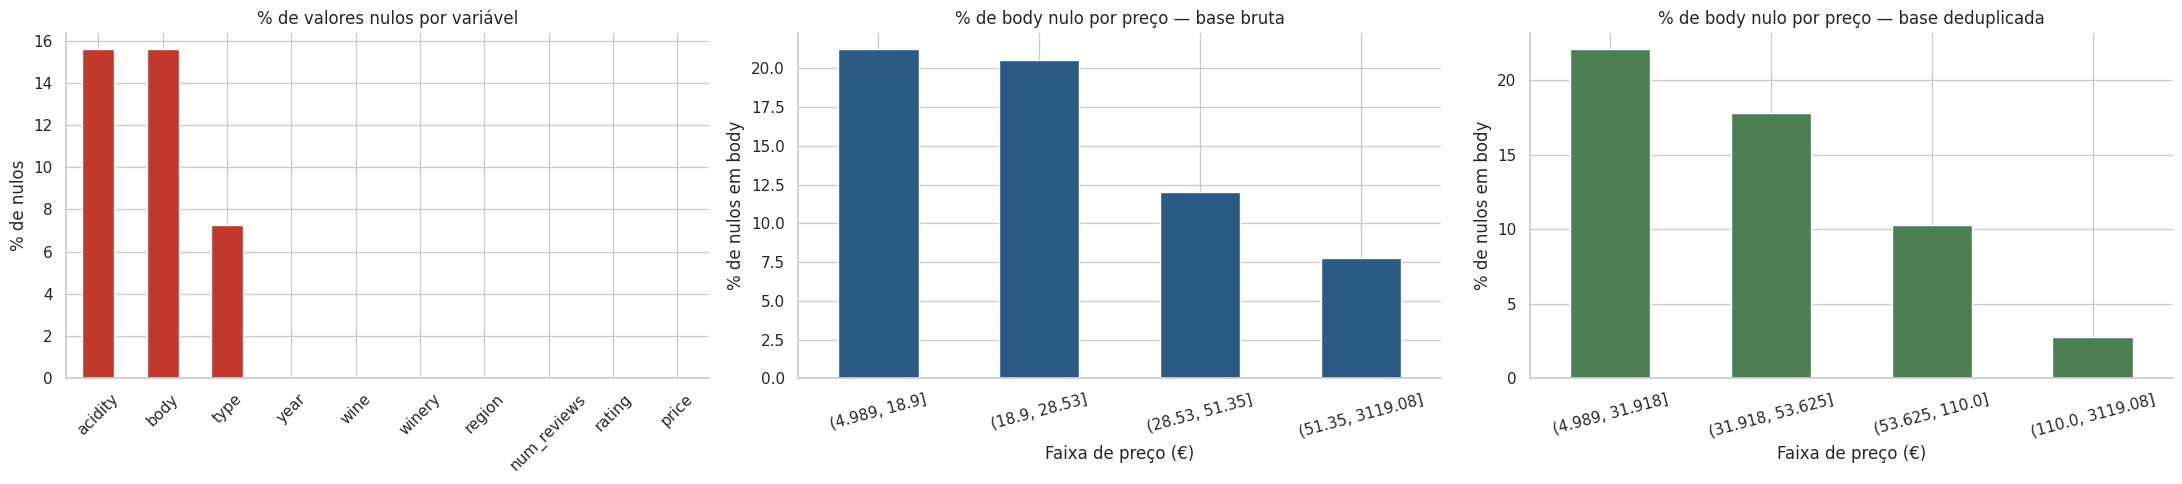

In [78]:
# @title Diagnóstico dos valores nulos

display(Markdown("#### Contagem de nulos por variável"))
print(df.isnull().sum())

nb = df['body'].isna()
na = df['acidity'].isna()
print(f"\nbody e acidity ausentes nos MESMOS registros: {(nb & na).sum()} "
      f"(em apenas um deles: {(nb ^ na).sum()})")
print(f"Desses {nb.sum()} registros, {df.loc[nb, 'type'].isna().sum()} "
      f"também não possuem 'type' (vinhos sem metadados).")
print(f"\nrating médio  ->  com body: {df.loc[~nb, 'rating'].mean():.3f}  |  "
      f"sem body: {df.loc[nb, 'rating'].mean():.3f}")

# Relação da ausência com o preço (quartis), na base bruta e na base sem duplicatas exatas.
def taxa_nulos_body_por_preco(data):
    base = data.copy()
    base['_fx_preco'] = pd.qcut(base['price'], 4, duplicates='drop')
    return (base.groupby('_fx_preco', observed=True)['body']
                .apply(lambda s: s.isna().mean() * 100))

null_por_preco_bruta = taxa_nulos_body_por_preco(df)
null_por_preco_dedup = taxa_nulos_body_por_preco(df.drop_duplicates())

display(Markdown("#### % de body nulo por faixa de preço"))
display(pd.concat([
    null_por_preco_bruta.rename('base_bruta_%'),
    null_por_preco_dedup.rename('base_deduplicada_%')
], axis=1).round(2))

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

(df.isnull().mean().mul(100)
   .sort_values(ascending=False)
   .plot(kind='bar', ax=axes[0], color='#c0392b'))
axes[0].set(title="% de valores nulos por variável", ylabel="% de nulos", xlabel="")
axes[0].tick_params(axis='x', rotation=45)

null_por_preco_bruta.plot(kind='bar', ax=axes[1], color='#2b5b84')
axes[1].set(title="% de body nulo por preço — base bruta",
            ylabel="% de nulos em body", xlabel="Faixa de preço (€)")
axes[1].tick_params(axis='x', rotation=15)

null_por_preco_dedup.plot(kind='bar', ax=axes[2], color='#4b7f52')
axes[2].set(title="% de body nulo por preço — base deduplicada",
            ylabel="% de nulos em body", xlabel="Faixa de preço (€)")
axes[2].tick_params(axis='x', rotation=15)

sns.despine()
plt.tight_layout()
plt.show()


### Leitura do diagnóstico e decisões

**O que os dados mostram:**

1. `body` e `acidity` estão ausentes **exatamente nos mesmos 1.169 registros**.
2. Desses, **545 também não têm `type`**.
3. A taxa de ausência **cai conforme o preço sobe**. Na base bruta, sai de cerca de 21% nos quartis mais baratos para ~8% no quartil mais caro; na base deduplicada, a queda fica ainda mais clara.
4. O `rating` quase não muda entre presentes e ausentes, então a nota não parece ser o principal eixo associado à ausência.

Esses padrões são **evidência contra MCAR** (*Missing Completely At Random*), pois a ausência não parece aleatória em relação às variáveis observadas. Porém, eles **não provam MAR**. A leitura mais rigorosa é: os dados são **compatíveis com um mecanismo MAR condicionado a variáveis observadas, especialmente preço**, mas ainda pode haver componente MNAR ou viés de cobertura da plataforma.

**Estratégias consideradas e por que foram (ou não) escolhidas:**

| Estratégia | Decisão | Motivo |
|---|---|---|
| Excluir linhas (listwise) | ❌ | Perderia ~15,6% dos dados e tenderia a enviesar a amostra, já que a ausência é maior em faixas de preço mais baixas. |
| Preencher com 0 | ❌ | 0 está **fora da escala** (`body` 2-5, `acidity` 1-3); cria categoria fantasma e gerou artefato de correlação. |
| Média global | ❌ | Ignora a dependência de `type`; produz valor não-inteiro, pouco interpretável em escala ordinal. |
| **Mediana por `type` + flag de ausência** | ✅ | Respeita a escala ordinal, usa um agrupamento substantivamente relevante e preserva o sinal de ausência por meio das flags. |
| `type` ausente → categoria nova | ❌ | Criaria um rótulo artificial que distorceria análises por tipo (Q3, Q6). Preferimos manter `type` nulo e usar a mediana global apenas como *fallback* da imputação. |

**Decisão final:** imputar `body` e `acidity` pela **mediana do respectivo `type`** (com *fallback* na mediana global para os registros sem tipo), criar as flags `body_informado` / `acidity_informado`, e converter os 2 nulos de `year` para `'N.V.'` (sem safra definida).


In [ ]:
# @title Aplicação do tratamento de nulos

# 1) Flags de ausência — a ausência é informativa (padrão MAR, ligado ao preço).
#    Preservar esse sinal permite explorar diversas possibilidades sem alterar o dataframe
df['body_informado'] = df['body'].notna().astype(int)
df['acidity_informado'] = df['acidity'].notna().astype(int)

# 2) Imputação ordinal: mediana do próprio 'type' (body/acidity são
#    essencialmente uma propriedade do tipo de vinho). Fallback = mediana
#    global para os 545 registros que também não têm 'type'.
for col in ['body', 'acidity']:
    df[col] = df.groupby('type')[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median()).astype(int)

# 3) year: os 2 nulos passam a 'N.V.' (tratados como não-vintage, sem safra).
df['year'] = df['year'].fillna('N.V.')

display(Markdown("#### Verificação após o tratamento"))
print("Nulos restantes:")
print(df[['body', 'acidity', 'year']].isnull().sum())
print(f"\n'type': {df['type'].isnull().sum()} nulos mantidos propositalmente")


#### Verificação após o tratamento

Nulos restantes:
body       0
acidity    0
year       0
dtype: int64

'type': 545 nulos mantidos propositalmente


### Validação e decisões de uso

**Resultado:** `body` e `acidity` ficam sem nenhum nulo. A distribuição reforça os níveis medianos dominantes (corpo 4, acidez 3), efeito esperado da imputação por mediana. Esse procedimento é preferível a descartar os registros, mas suas consequências precisam ser sinalizadas.

| Par | Preenchimento com 0 | Imputação por `type` | Observado (dados reais) |
|---|---:|---:|---:|
| `body` ↔ `acidity` | **0.92** (crítico) | **−0.02** | −0.018 |
| `body` ↔ `rating` | 0.138 | 0.161 | 0.163 |
| `body` ↔ `price` | 0.133 | 0.155 | 0.154 |

Essa validação usa correlação de Pearson apenas como diagnóstico rápido de distorção. Como `body` e `acidity` são escalas **ordinais discretas**, as conclusões substantivas do notebook passam a priorizar Spearman, comparações de medianas e tamanhos de efeito por grupos.

**Como isso afeta o restante do notebook:**

- As análises gerais podem usar a base imputada para manter cobertura completa.
- Perguntas que dependem diretamente de `body` ou `acidity` usam `body_informado` / `acidity_informado` para considerar apenas valores originalmente medidos.
- As conclusões são formuladas como **associações observadas**, não como efeitos causais.
---


## Tratamento de Tipos e Formatação

Com os nulos já resolvidos na etapa anterior, padroniza-se `price` (float com 2 casas decimais) e garante-se o tipo inteiro de `body`/`acidity`.

In [80]:
# @title Tratamento de tipos e formatação
df['price'] = df['price'].astype(float)   # Convertendo para float
df['price'] = df['price'].round(2)        # Padronizando com duas casas decimais

# Os nulos de body/acidity já foram tratados na etapa "Tratamento de Valores Nulos";
# aqui apenas garantimos o tipo inteiro.
df['body'] = df['body'].astype(int)
df['acidity'] = df['acidity'].astype(int)

## Funções auxiliares de rigor estatístico

Como `body` e `acidity` são escalas ordinais e `price`/`num_reviews` são assimétricas, a análise passa a complementar Pearson com medidas mais adequadas: Spearman para associação monotônica, medianas por grupo e uma estatística de Kruskal-Wallis com tamanho de efeito aproximado (`epsilon²`).


In [81]:
# @title Funções auxiliares para variáveis ordinais

def kruskal_epsilon2(data, group_col, value_col):
    """Calcula H de Kruskal-Wallis e epsilon² a partir de ranks.

    O objetivo aqui é descritivo: comparar grupos e reportar tamanho de efeito
    sem depender de bibliotecas externas além de pandas/numpy.
    """
    base = data[[group_col, value_col]].dropna().copy()
    base = base.groupby(group_col, observed=True).filter(lambda g: len(g) > 0)
    n = len(base)
    k = base[group_col].nunique(dropna=True)

    if n <= k or k < 2:
        return pd.Series({'H': np.nan, 'epsilon2': np.nan, 'n': n, 'k': k})

    base['_rank'] = base[value_col].rank(method='average')
    grupos = base.groupby(group_col, observed=True)['_rank'].agg(['count', 'sum'])

    h = (12 / (n * (n + 1))) * ((grupos['sum'] ** 2 / grupos['count']).sum()) - 3 * (n + 1)

    ties = base[value_col].value_counts()
    tie_correction = 1 - ((ties ** 3 - ties).sum() / (n ** 3 - n))
    if tie_correction > 0:
        h = h / tie_correction

    epsilon2 = (h - k + 1) / (n - k)
    return pd.Series({'H': h, 'epsilon2': epsilon2, 'n': n, 'k': k})


def resumo_por_grupo(data, group_col, value_col):
    return (data.groupby(group_col, observed=True)[value_col]
            .agg(n='count', mediana='median', media='mean')
            .round(2))


## Perguntas e Hipóteses

> Cada pergunta recebeu um código (**Q1-Q8**) que é citado nos títulos dos gráficos e nas conclusões, para deixar explícito onde ela é respondida.

**Q1. Há uma relação entre a avaliação e o preço do vinho?**

Hipótese: Vinhos com avaliações mais altas tendem a aparecer em faixas de preço mais elevadas.

**Q2. A região do vinho está associada à sua avaliação?**

Hipótese: Vinhos produzidos em regiões renomadas tendem a apresentar avaliações médias ligeiramente superiores.

**Q3. O tipo de vinho está associado ao valor?**

Hipótese: Existem tipos de vinho associados a faixas de preço mais altas, por combinação de região, estilo, safra, marca e variedade.

**Q4. Qual a relação entre avaliação, preço e ano?**

Hipótese: Vinhos de safras mais antigas e com notas altas tendem a aparecer em faixas de preço mais elevadas.

**Q5. Existe relação entre preço e quantidade de reviews?**

Hipótese: Por serem mais acessíveis, vinhos mais baratos poderiam receber mais reviews do que vinhos mais caros.

**Q6. Como a diversidade de tipos de vinho varia entre as 10 principais regiões produtoras?**

Hipótese: Algumas regiões apresentam composição de tipos mais diversa do que outras, seja por variedade de estilos, tradição ou por serem categorias regionais mais genéricas.

**Q7. Como o corpo do vinho se associa ao preço entre vinhos com `rating >= 4.5` em diferentes regiões da Espanha?**

Hipótese: Entre vinhos de avaliação alta, níveis mais intensos de corpo tendem a estar associados a preços mais elevados, com variação por região.

**Q8. A acidez do vinho está associada ao preço?**

Hipótese: Vinhos com acidez moderada tendem a aparecer em faixas de preço mais altas.

---

### Onde cada pergunta é respondida

| Pergunta | Categoria de análise | Célula(s) |
|---|---|---|
| **Q1** – avaliação × preço | Bivariada / Multivariada | *Comportamento par a par*, *Matrizes de associação*, *Mapa de Calor e Dispersão* |
| **Q2** – região × avaliação | Bivariada | *Q2 — Região × Avaliação* (+ recorte em Q4) |
| **Q3** – tipo × preço | Bivariada | *Q3 — Tipo × Preço* |
| **Q4** – avaliação, preço e ano | Multivariada | *Distribuição Conjunta (era × região)* |
| **Q5** – preço × nº de reviews | Bivariada | *Comportamento par a par*, *Matrizes de associação* |
| **Q6** – diversidade de tipos por região | Bivariada (qual × qual) | *Q6 — Diversidade de tipos por região* |
| **Q7** – corpo × preço × região (`rating >= 4.5`) | Multivariada | *Q7 — Corpo × Preço × Região* |
| **Q8** – acidez × preço | Bivariada | *Q8 — Acidez × Preço* |


## Análise Univariada

In [82]:
# @title Resumo Estatístico

display(Markdown("#### Variáveis Qualitativas"))
display(df.describe(include='str'))

display(Markdown("#### Variáveis Quantitativas"))
display(df.describe())

#### Variáveis Qualitativas

,winery,wine,year,region,type
count,7500,7500,7500,7500,6955
unique,480,847,71,76,21
top,Contino,Reserva,2011,Rioja,Rioja Red
freq,457,467,1190,2440,2357


#### Variáveis Quantitativas

,rating,num_reviews,price,body,acidity,body_informado,acidity_informado
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,4.254933,451.109067,60.095823,4.147333,2.951867,0.844133,0.844133
std,0.118029,723.001856,150.356676,0.564567,0.234856,0.362753,0.362753
min,4.200000,25.000000,4.990000,2.000000,1.000000,0.000000,0.000000
25%,4.200000,389.000000,18.900000,4.000000,3.000000,1.000000,1.000000
50%,4.200000,404.000000,28.530000,4.000000,3.000000,1.000000,1.000000
75%,4.200000,415.000000,51.350000,4.000000,3.000000,1.000000,1.000000
max,4.900000,32624.000000,3119.080000,5.000000,3.000000,1.000000,1.000000


### Distribuição de Variáveis

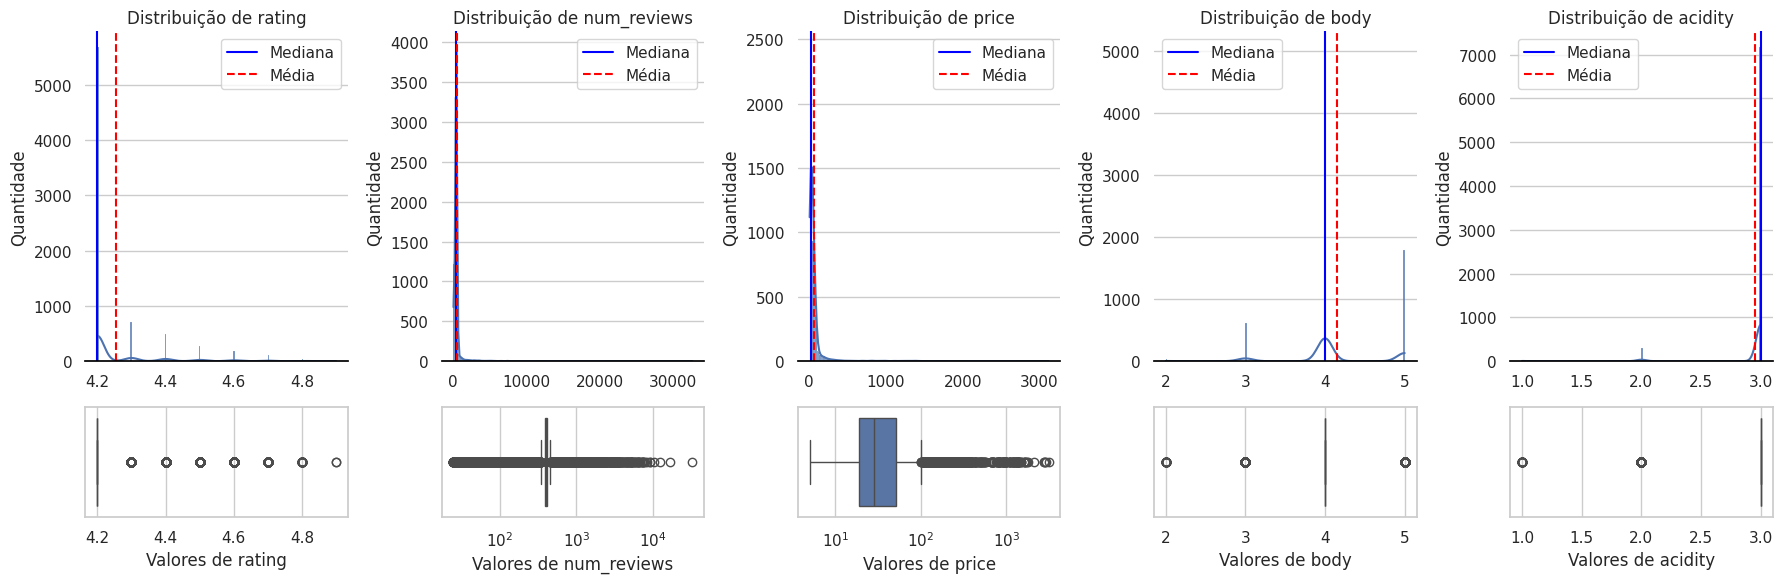

In [83]:
# @title Variáveis Quantitativas  (univariada — base p/ Q1, Q5, Q7, Q8)

variaveis_quantitativas = df_dict.query("tipo == 'quantitativa'").variavel.to_list()

fig, axes = plt.subplots(figsize=(18, 6), ncols=len(variaveis_quantitativas), nrows=2,
                         gridspec_kw={"height_ratios": [3, 1]})

for i, variavel in enumerate(variaveis_quantitativas):

    use_log = True if variavel in ['price', 'num_reviews'] else False


    ax = sns.histplot(data=df, x=variavel, ax=axes[0, i], kde=True, alpha=.8)


    mediana = df[variavel].median()
    media = df[variavel].mean()

    ax.axvline(mediana, color="blue", label="Mediana")
    ax.axvline(media, color="red", linestyle="--", label="Média")

    ax.set(title=f"Distribuição de {variavel}", ylabel="Quantidade", xlabel="")
    ax.legend()


    ax.spines["bottom"].set_color("black")
    ax.grid(False, axis="x")
    for side in ["left", "top", "right"]:
        ax.spines[side].set_visible(False)


    ax_box = sns.boxplot(data=df, x=variavel, ax=axes[1, i])
    if use_log:
        ax_box.set_xscale('log')
    ax_box.set(xlabel=f"Valores de {variavel}")

plt.tight_layout()
plt.show()

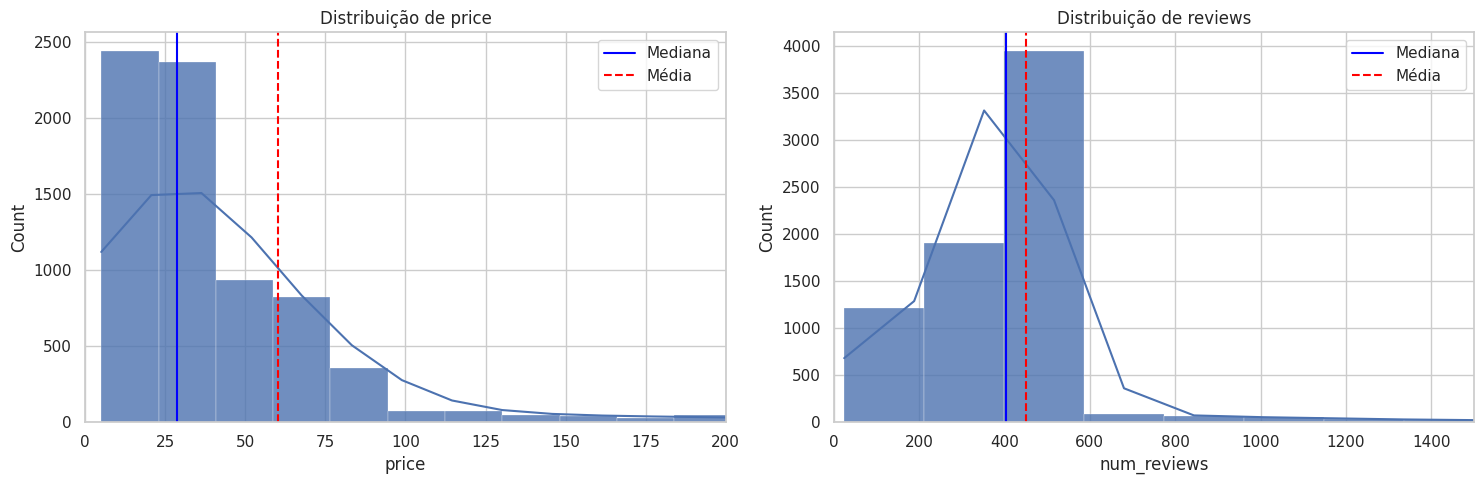

In [84]:
#Melhoria na visualização dos gráficos de preço e número de avaliações.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df, x="price", kde=True, alpha=0.8, ax=axes[0])

mediana_price = df["price"].median()
media_price = df["price"].mean()

axes[0].axvline(mediana_price, color="blue", label="Mediana")
axes[0].axvline(media_price, color="red", linestyle="--", label="Média")
axes[0].set(title="Distribuição de price", xlim=(0, 200))
axes[0].legend()

sns.histplot(data=df, x="num_reviews", kde=True, alpha=0.8, ax=axes[1])

mediana_reviews = df["num_reviews"].median()
media_reviews = df["num_reviews"].mean()

axes[1].axvline(mediana_reviews, color="blue", label="Mediana")
axes[1].axvline(media_reviews, color="red", linestyle="--", label="Média")
axes[1].set(title="Distribuição de reviews", xlim=(0, 1500))
axes[1].legend()

plt.tight_layout()

plt.show()

---

> *Análise descritiva (univariada) — serve de base de leitura para as perguntas relacionais **Q1, Q5, Q7 e Q8**.*

**Distribuição da variável rating**

- A maior parte dos vinhos está concentrada na nota 4.2, que coincide com a mediana e também é o valor mais frequente do conjunto (5.679 de 7.500 registros).

- As notas acima de 4.2 aparecem de forma mais isolada (a nota 4.9 tem apenas 2 vinhos), o que indica que avaliações muito altas existem, mas são exceções dentro do dataset.

**Distribuição da variável num_reviews**

- Ao contrário do que a forma do histograma sugere, os vinhos **não** se concentram próximo de zero: o mínimo é 25 avaliações e o intervalo interquartil é bastante estreito (entre 389 e 415), com mediana de 404.

- O histograma parece "achatado" à esquerda apenas porque alguns poucos vinhos possuem um volume extremamente alto de avaliações (mais de 32.000), atuando como outliers que esticam a escala. O boxplot em escala logarítmica torna essa concentração em torno de ~400 muito mais visível.

**Distribuição da variável price**

- A maioria dos preços está concentrada em valores baixos (75% dos vinhos custam até ~51€ e a mediana é 28,53€).

- Fica evidente uma diferença considerável entre média (60,10€) e mediana (28,53€), sugerindo que vinhos muito caros (até 3.119€) puxam a média para cima e distorcem a percepção do preço "típico".

**Distribuição das variáveis body e acidity**

- Não há mais barra em "0": os 1.169 valores ausentes foram imputados na etapa *Tratamento de Valores Nulos* pela mediana do respectivo `type`, preservando a escala ordinal.

- A maior parte dos vinhos tem **corpo nível 4** (5.061 registros), seguido pelo nível 5 (1.791); os corpos mais leves 3 e 2 são raros (610 e 38). A média fica em ~4,15 — antes era artificialmente puxada para ~3,51 pelo antigo preenchimento com 0.

- A **acidez** concentra-se fortemente no **nível 3** (7.174 registros); os níveis 2 e 1 são raros (291 e 35). Como a imputação usa a mediana por `type`, ela reforça os níveis medianos dominantes (4 em body, 3 em acidity) — efeito esperado e justificado na etapa de tratamento.

---


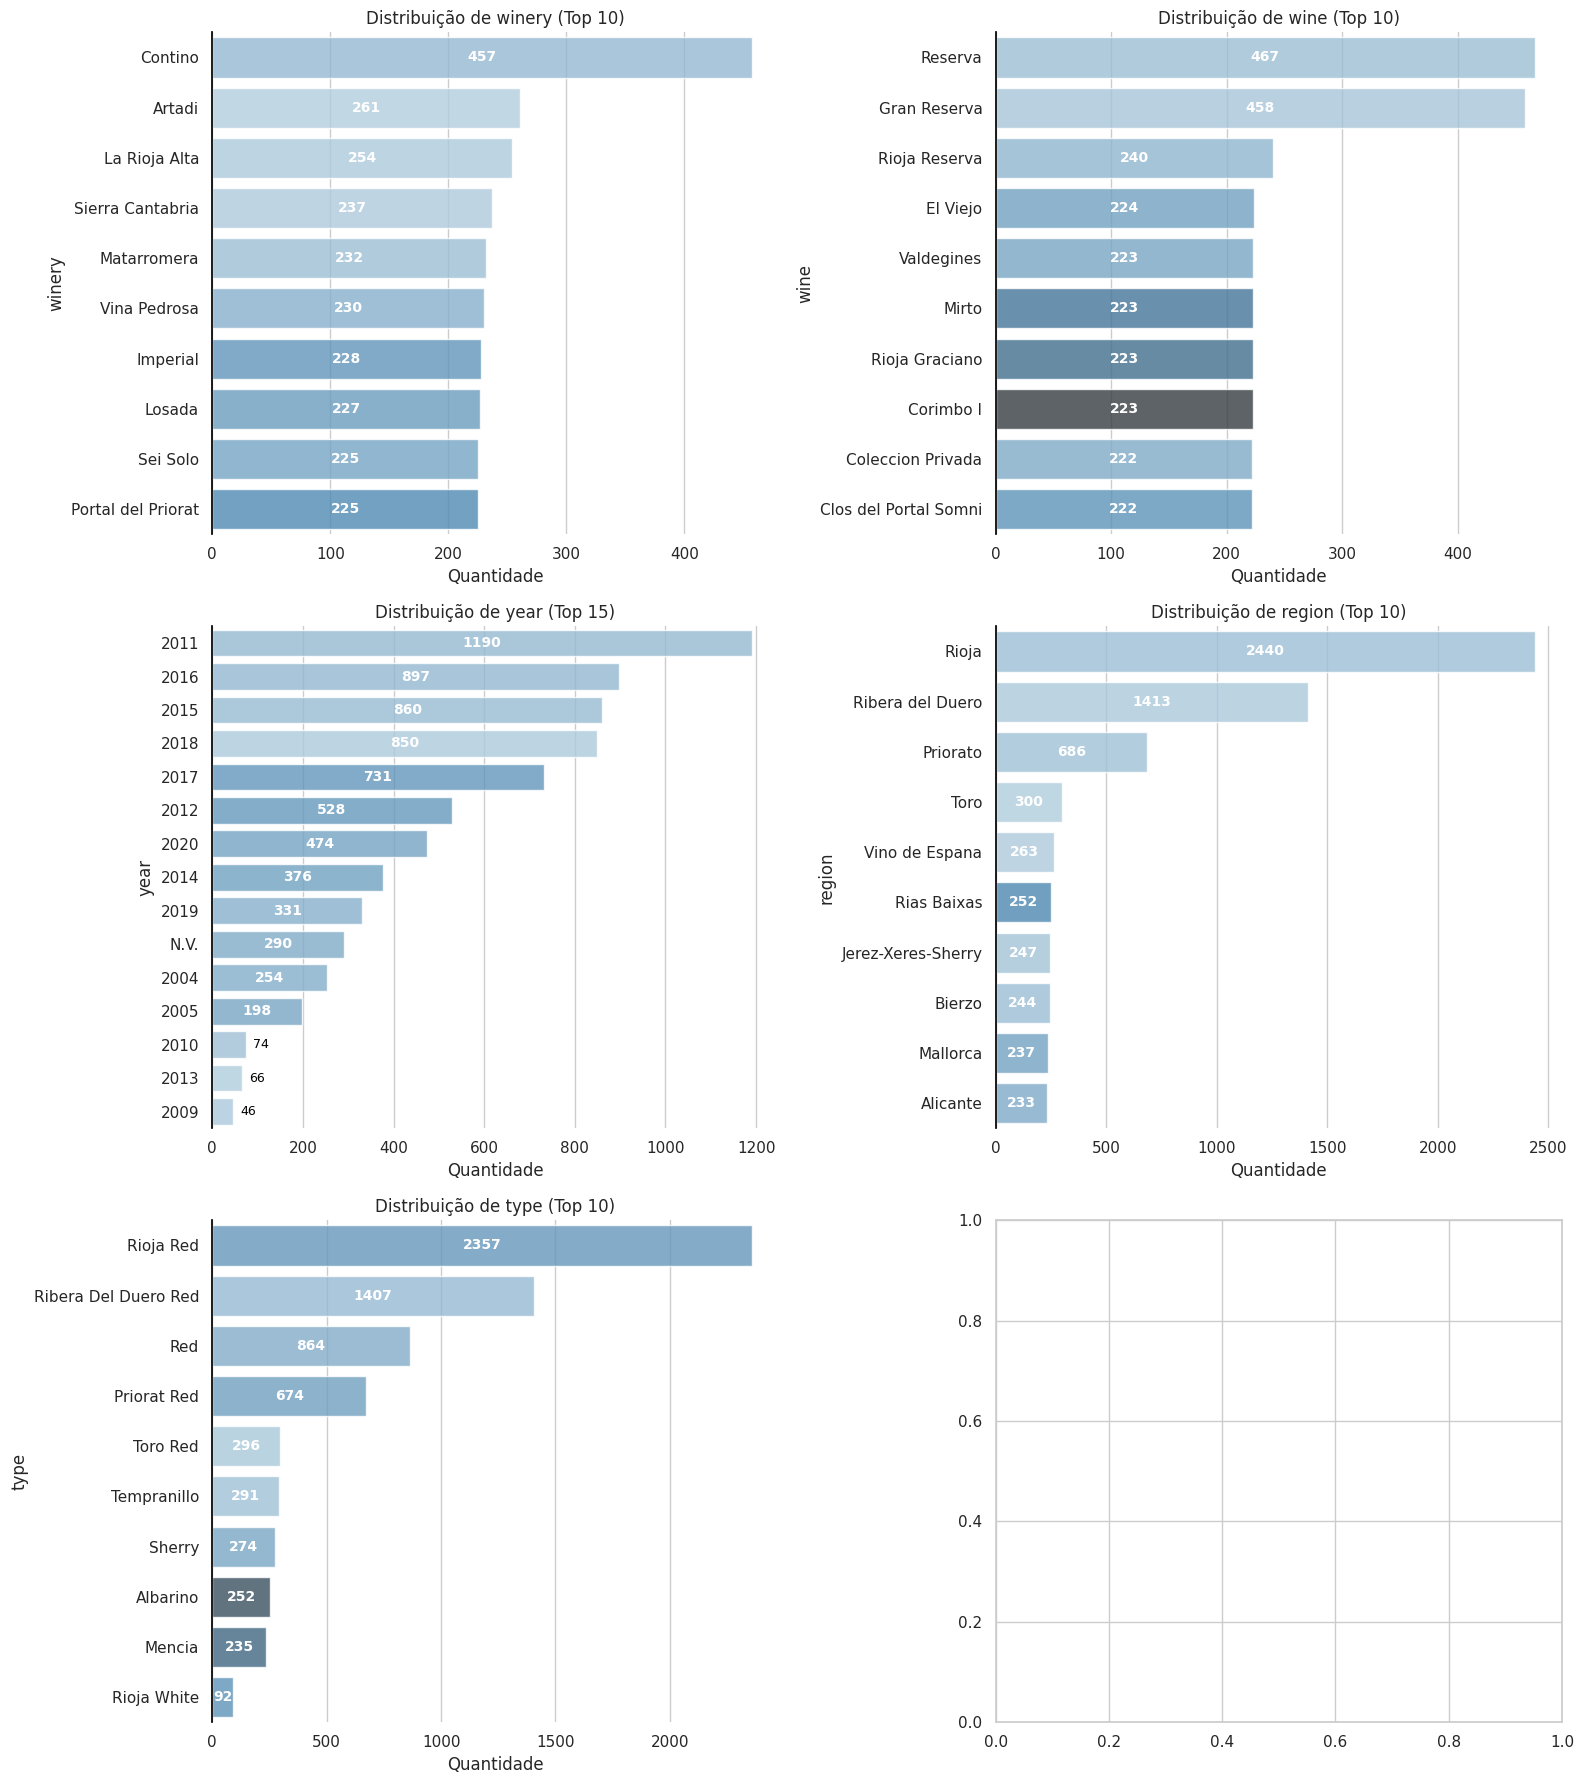

In [85]:
# @title Variáveis Qualitativas  (univariada — base p/ Q3, Q6)

variaveis_qualitativas = df_dict.query("tipo == 'qualitativa'").variavel.to_list()

fig, axes = plt.subplots(figsize=(16, 18), ncols=2, nrows=3)
axes = axes.flatten()

for i, variavel in enumerate(variaveis_qualitativas):
    top_n = 15 if variavel == "year" else 10
    order = df[variavel].value_counts().index[:top_n]

    ax = sns.countplot(data=df, y=variavel, ax=axes[i], order=order, palette="Blues_d", hue=variavel, legend=False, alpha=.8)

    for bar in ax.patches:
        width = bar.get_width()

        if width > 80:
            ax.text(width/2, bar.get_y() + bar.get_height()/2,
                   f'{int(width)}',
                   ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        else:
            ax.text(width + 15, bar.get_y() + bar.get_height()/2,
                   f'{int(width)}',
                   ha='left', va='center', color='black', fontsize=9)

    ax.set(title=f"Distribuição de {variavel} (Top {top_n})", xlabel="Quantidade")

    for side in ["bottom", "top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color("black")

plt.tight_layout()
plt.show()

---

**Winery (Vinícola)**
 - A vinícola Contino é a que possui a maior quantidade de rótulos no dataset, destacando-se das demais que mantêm uma distribuição mais equilibrada entre 200 e 300 unidades.

**Wine (Vinho)**
-  Os nomes de vinhos mais frequentes são Reserva (467) e Gran Reserva (458).

**Year (Ano)**
- O ano de 2011 é a safra com maior presença absoluta, com quase 1.200 registros. É interessante notar a presença da categoria "N.V." entre os mais frequentes, representando vinhos sem uma safra específica definida.

**Region (Região)**
- A região de Rioja é a principal origem dos vinhos, com mais de 2.400 registros, seguida por Ribera del Duero. Juntas, elas dominam grande parte da amostra.

**Type (Tipo)**
- O tipo Rioja Red é o mais comum, o que é coerente com a dominância da região de Rioja observada anteriormente.

---

## Análise Bivariada

### Relação entre variáveis quantitativas

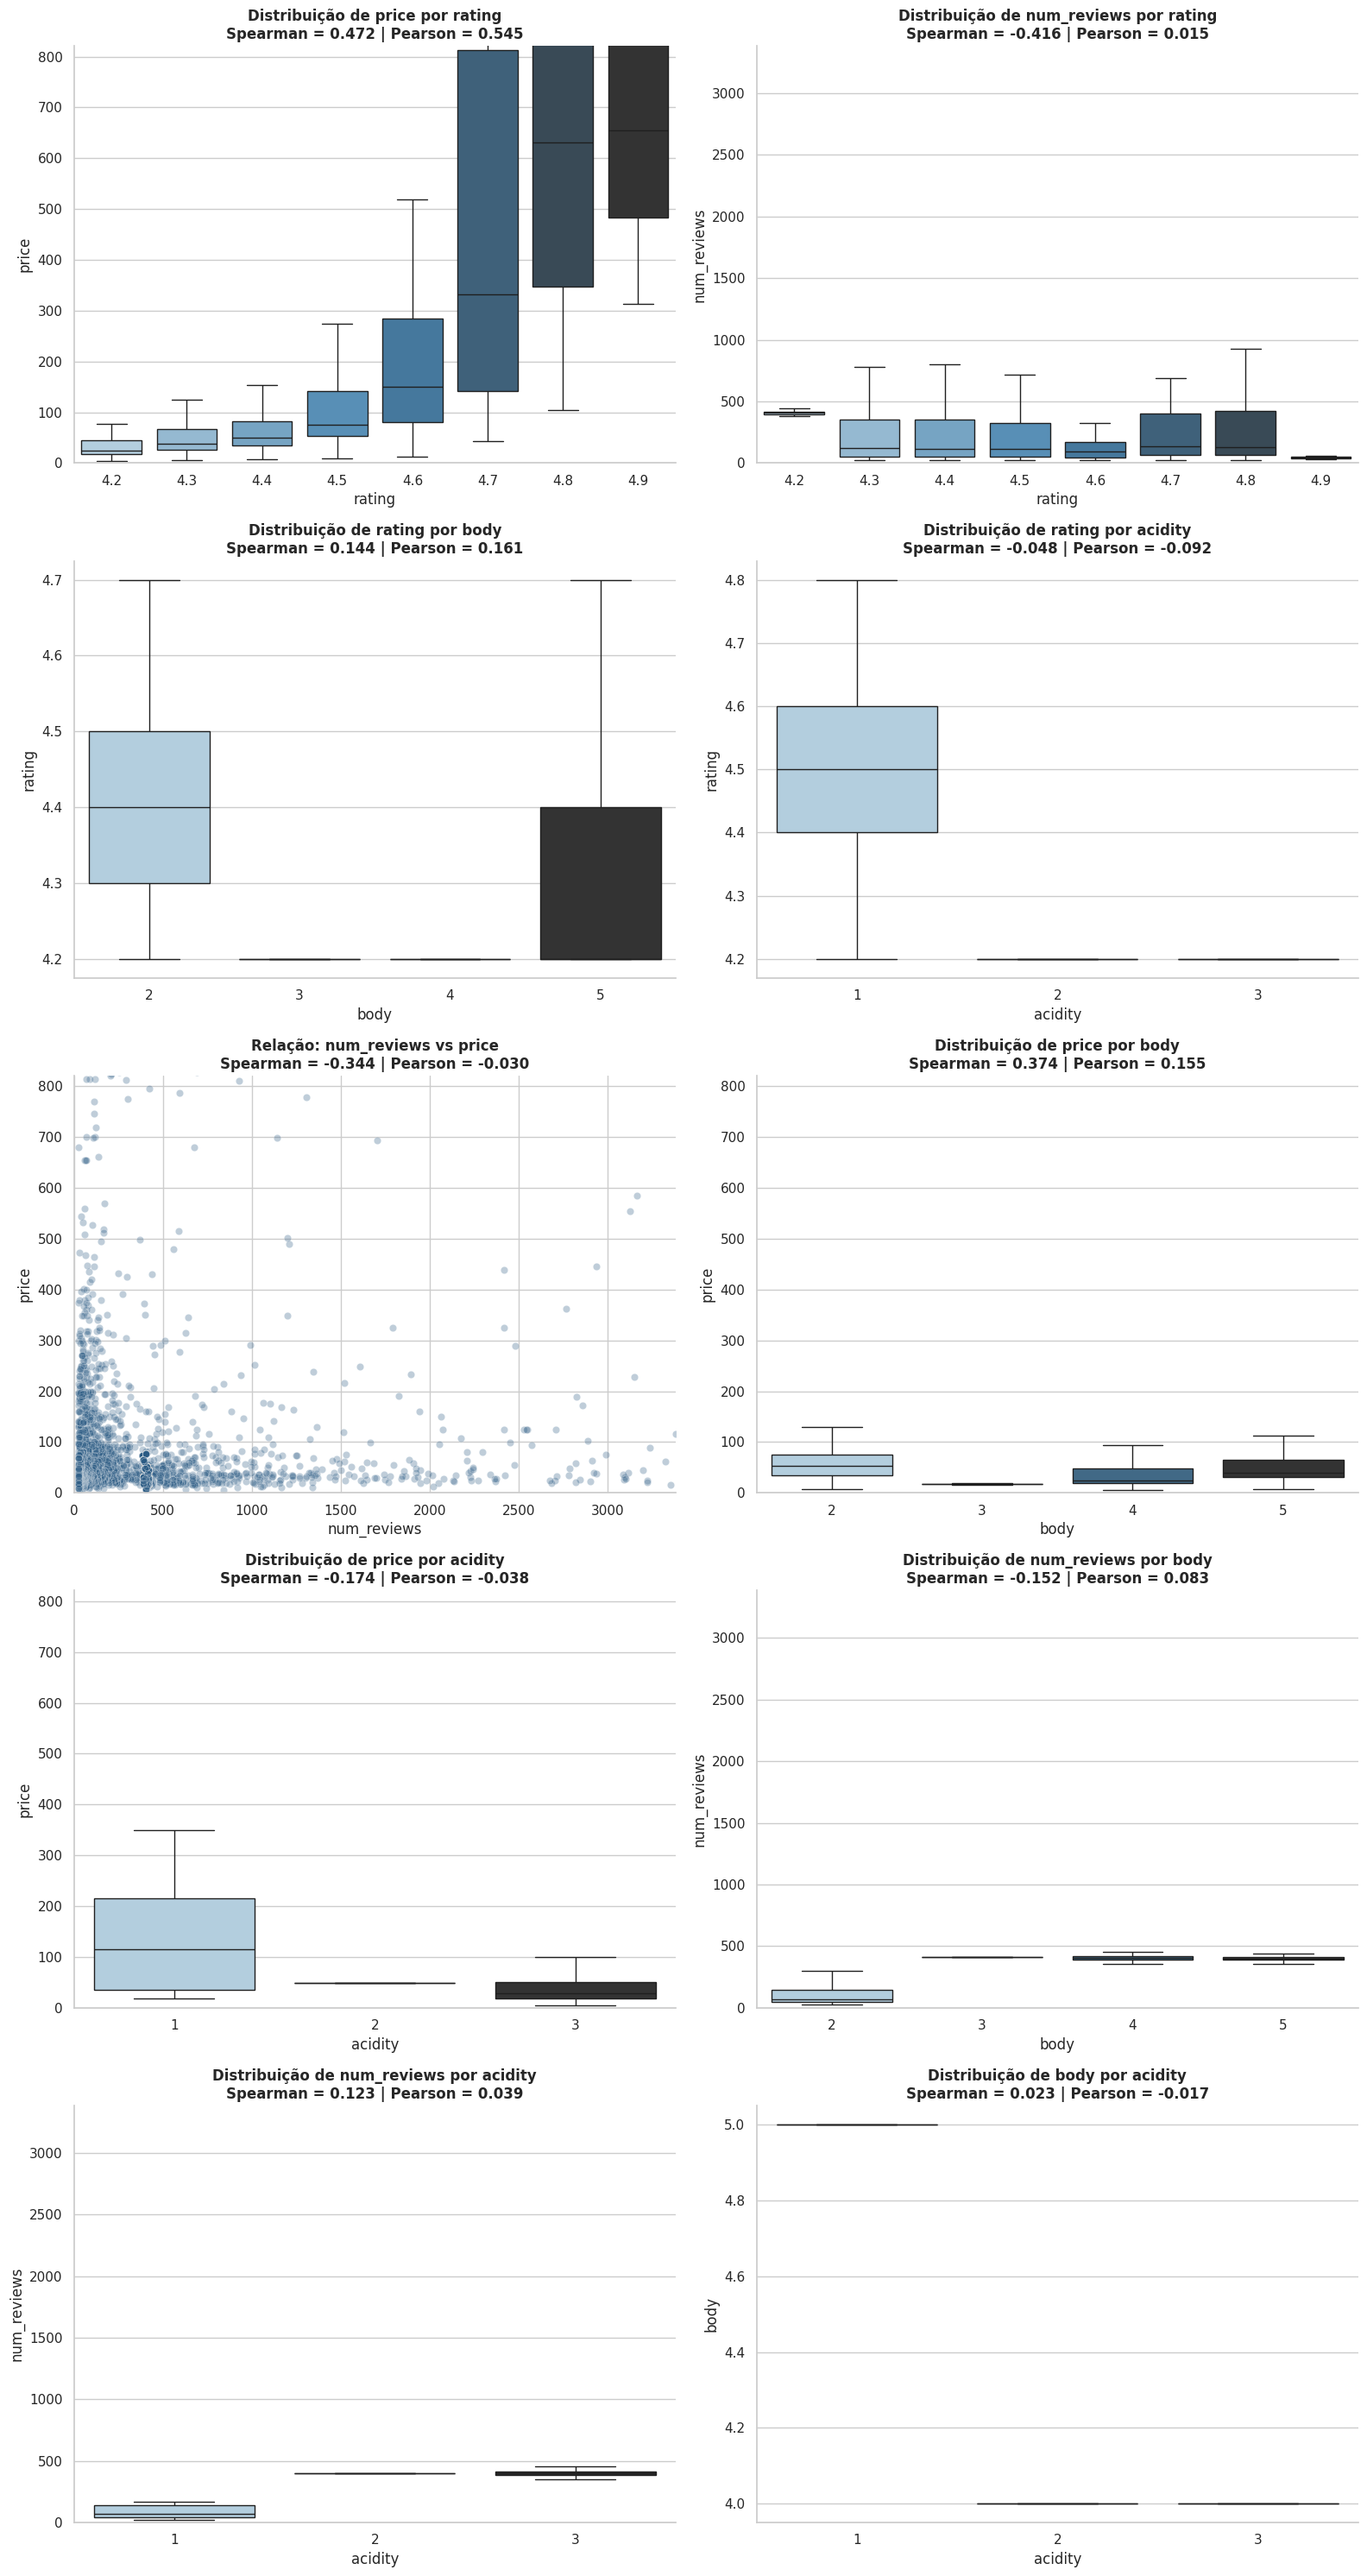

In [86]:
# @title Comportamento par a par — associações e distribuições

vars_quant = ['rating', 'price', 'num_reviews', 'body', 'acidity']
ordinal_vars = {'rating', 'body', 'acidity'}
combinacoes = list(itertools.combinations(vars_quant, 2))

fig, axes = plt.subplots(figsize=(16, 30), ncols=2, nrows=5)
axes = axes.flatten()

def limitar_eixo(ax, eixo, variavel):
    if variavel in ['price', 'num_reviews']:
        limite = df[variavel].quantile(.99)
        if eixo == 'x':
            ax.set_xlim(0, limite)
        else:
            ax.set_ylim(0, limite)

for i, (v1, v2) in enumerate(combinacoes):
    pearson = df[[v1, v2]].corr(method='pearson').iloc[0, 1]
    spearman = df[[v1, v2]].corr(method='spearman').iloc[0, 1]

    if v1 in ordinal_vars or v2 in ordinal_vars or df[v1].nunique() <= 10 or df[v2].nunique() <= 10:
        x_var, y_var = (v1, v2) if df[v1].nunique() <= df[v2].nunique() else (v2, v1)
        sns.boxplot(data=df, x=x_var, y=y_var, ax=axes[i],
                    palette="Blues_d", hue=x_var, legend=False, showfliers=False)
        limitar_eixo(axes[i], 'y', y_var)
        axes[i].set_title(
            f"Distribuição de {y_var} por {x_var}\nSpearman = {spearman:.3f} | Pearson = {pearson:.3f}",
            fontsize=12, fontweight='bold'
        )
    else:
        sns.scatterplot(data=df, x=v2, y=v1, ax=axes[i], alpha=0.3, color='#2b5b84')
        limitar_eixo(axes[i], 'x', v2)
        limitar_eixo(axes[i], 'y', v1)
        axes[i].set_title(
            f"Relação: {v2} vs {v1}\nSpearman = {spearman:.3f} | Pearson = {pearson:.3f}",
            fontsize=12, fontweight='bold'
        )

    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()


---

> **Perguntas respondidas aqui:** **Q1** (avaliação × preço) e **Q5** (preço × nº de reviews). Também é a base para **Q7** (corpo × preço) e **Q8** (acidez × preço), aprofundadas em células dedicadas.

### Análise do Comportamento Par a Par

Nesta etapa, foram analisadas as relações entre as principais variáveis do dataset. Para reduzir distorções visuais, os eixos de `price` e `num_reviews` são limitados ao percentil 99 quando necessário, e os outliers são ocultados nos boxplots. Isso melhora a leitura sem apagar a existência de valores extremos.

Como `body`, `acidity` e `rating` têm natureza ordinal/discreta, cada gráfico passa a exibir **Spearman** junto de **Pearson**. Pearson continua útil como referência linear, mas a leitura substantiva prioriza associações monotônicas, medianas e distribuições por grupo.

#### Principais insights

**Preço vs. Rating — Q1**

- A associação é positiva: vinhos com ratings maiores tendem a ocupar faixas de preço mais altas. A forma da relação é mais bem lida em escala logarítmica de preço, aprofundada no bloco de Q1.

**Número de reviews — Q5**

- A relação linear entre `num_reviews` e preço/rating é fraca. A leitura por Spearman ajuda a verificar se existe alguma tendência monotônica, mas a hipótese original de que vinhos baratos receberiam claramente mais reviews não se sustenta de forma robusta.

**Body e acidity**

- `body` e `acidity` são escalas ordinais; portanto, não devem ser lidas como medidas contínuas. As análises dedicadas de Q7 e Q8 usam valores originalmente medidos e comparam medianas/tamanhos de efeito por grupo.

---


### Correlação

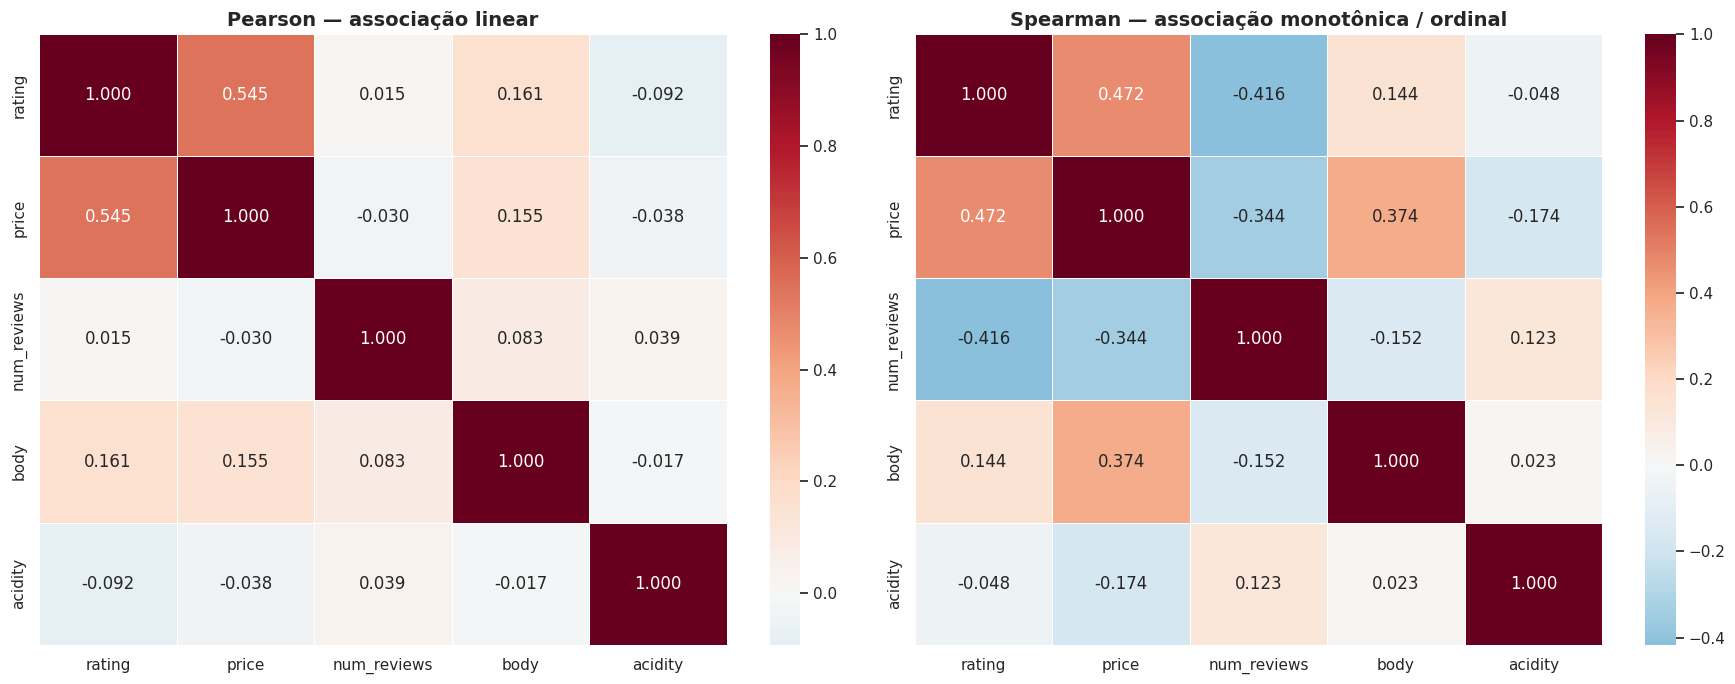

In [87]:
# @title Matrizes de associação — Pearson e Spearman

cols_quant = ['rating', 'price', 'num_reviews', 'body', 'acidity']
corr_pearson = df[cols_quant].corr(method='pearson')
corr_spearman = df[cols_quant].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_pearson, annot=True, fmt=".3f", cmap='RdBu_r', center=0,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Pearson — associação linear', fontsize=14, fontweight='bold')

sns.heatmap(corr_spearman, annot=True, fmt=".3f", cmap='RdBu_r', center=0,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Spearman — associação monotônica / ordinal', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


---
- A matriz de **Pearson** resume relações lineares e é útil para comparar com versões anteriores da análise.
- A matriz de **Spearman** é a referência principal quando entram `rating`, `body` e `acidity`, pois essas variáveis têm poucos níveis ordenados.
- `body` e `acidity` não devem ser interpretados como variáveis contínuas finas; para elas, a leitura mais rigorosa vem de medianas por grupo e tamanhos de efeito.
---


> **Síntese consolidada das perguntas Q1, Q5 e Q8** (visão geral das associações, já com `body`/`acidity` imputados por `type`).

**Preço e avaliação — Q1**

- `rating` e `price` apresentam associação positiva: vinhos melhor avaliados tendem a aparecer em faixas de preço mais altas. A análise com `price_log` aprofunda essa relação sem assumir causalidade.

**Num_reviews, preço e rating — Q5**

- A relação linear é fraca. Portanto, a hipótese de que vinhos baratos receberiam claramente mais reviews não se sustenta nesta EDA. A leitura por Spearman ajuda a checar tendência monotônica, mas ainda não autoriza afirmar independência causal entre popularidade, preço e nota.

**Body e acidity**

- Como são escalas ordinais, seus coeficientes são tratados como diagnóstico exploratório. As respostas finais de Q7 e Q8 usam apenas valores originalmente medidos e comparam grupos por mediana e tamanho de efeito.

> **Cautela metodológica:** todas as conclusões deste notebook são formuladas como associações observadas. Termos como "afeta", "explica" ou "influencia" são evitados quando não há modelo causal ou controle multivariado suficiente.
---


### Q8 — Acidez × Preço

*Análise bivariada (quantitativa)* — relação entre o nível de acidez e o `price`, usando **apenas os registros com acidez originalmente medida** (flag `acidity_informado`, criada no *Tratamento de Valores Nulos*), para responder com base em dados reais e não em valores imputados.

,n,mediana,media
acidity,,,
1,35,114.50,148.87
2,268,48.96,75.33
3,6028,28.53,64.80


#### Tamanho de efeito por ranks (Kruskal-Wallis descritivo)

,H,epsilon2,n,k
0,176.5426,0.0276,6331.0,3.0


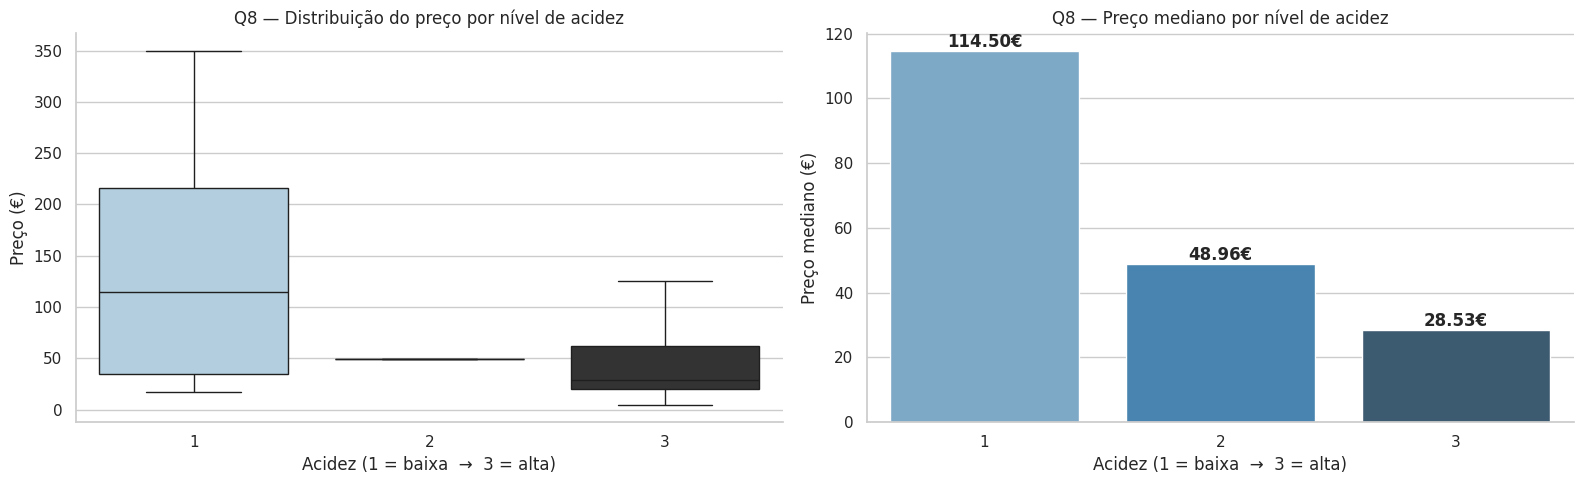

In [88]:
# @title Q8 — Acidez × Preço (responde Q8)

# Usa apenas registros com acidez ORIGINALMENTE medida (flag), não os imputados.
df_q8 = df[df['acidity_informado'] == 1].copy()

resumo_q8 = resumo_por_grupo(df_q8, 'acidity', 'price')
display(resumo_q8)

display(Markdown("#### Tamanho de efeito por ranks (Kruskal-Wallis descritivo)"))
display(kruskal_epsilon2(df_q8, 'acidity', 'price').to_frame().T.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df_q8, x='acidity', y='price', ax=axes[0],
            palette="Blues_d", hue='acidity', legend=False, showfliers=False)
axes[0].set(title="Q8 — Distribuição do preço por nível de acidez",
            xlabel="Acidez (1 = baixa  →  3 = alta)", ylabel="Preço (€)")

med_ac = df_q8.groupby('acidity')['price'].median()
sns.barplot(x=med_ac.index.astype(str), y=med_ac.values, ax=axes[1],
            palette="Blues_d", hue=med_ac.index.astype(str), legend=False)
for i, v in enumerate(med_ac.values):
    axes[1].text(i, v, f'{v:.2f}€', ha='center', va='bottom', fontweight='bold')
axes[1].set(title="Q8 — Preço mediano por nível de acidez",
            xlabel="Acidez (1 = baixa  →  3 = alta)", ylabel="Preço mediano (€)")

sns.despine()
plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q8.** O cálculo usa apenas registros com acidez **originalmente medida** (`acidity_informado = 1`), evitando basear a conclusão em valores imputados.

| Acidez | Nº de vinhos | Preço mediano | Preço médio |
|---|---:|---:|---:|
| 1 (baixa) | 35 | 114,50€ | 148,87€ |
| 2 (média) | 268 | 48,96€ | 75,33€ |
| 3 (alta) | 6.028 | 28,53€ | 64,80€ |

A hipótese de que a acidez moderada teria preços mais altos **não se sustenta**. A tabela sugere preços maiores nos poucos vinhos de acidez baixa, mas essa leitura é frágil: `acidity = 1` tem apenas 35 registros e o desbalanceamento é muito forte.

**Conclusão:** não há base suficiente para afirmar uma relação geral entre menor acidez e maior preço. A conclusão mais rigorosa é apenas que, neste recorte, a hipótese original não foi confirmada e o padrão observado exige cautela.

---


### Relação entre variáveis qualitativas

---
#### Tratamento de Variáveis Qualitativas
Para realizar as análises de contingência e de distribuição relativa, alguns ajustes foram necessários no tratamento dos dados.

Como a variável **year** possui muitos valores únicos, a visualização direta em gráficos de barras ficaria pouco legível. Por isso, foi feita uma conversão temporária para o tipo numérico, permitindo o agrupamento em faixas de tempo (eras). Esse agrupamento facilita a identificação de padrões entre safras mais antigas e mais recentes.

Os registros classificados como "N.V." (não-vintage) foram desconsiderados nessa etapa específica, já que não possuem referência cronológica definida e poderiam comprometer a análise temporal.

Além disso, como o dataset contém apenas um país (Espanha — coluna já descartada na exploração inicial), as grades de subplots foram restritas aos principais **tipos de vinho** e às **eras**. Essa redução de categorias ajuda a evitar excesso de informação nos gráficos e mantém o foco nos segmentos com maior representatividade no dataset.

---


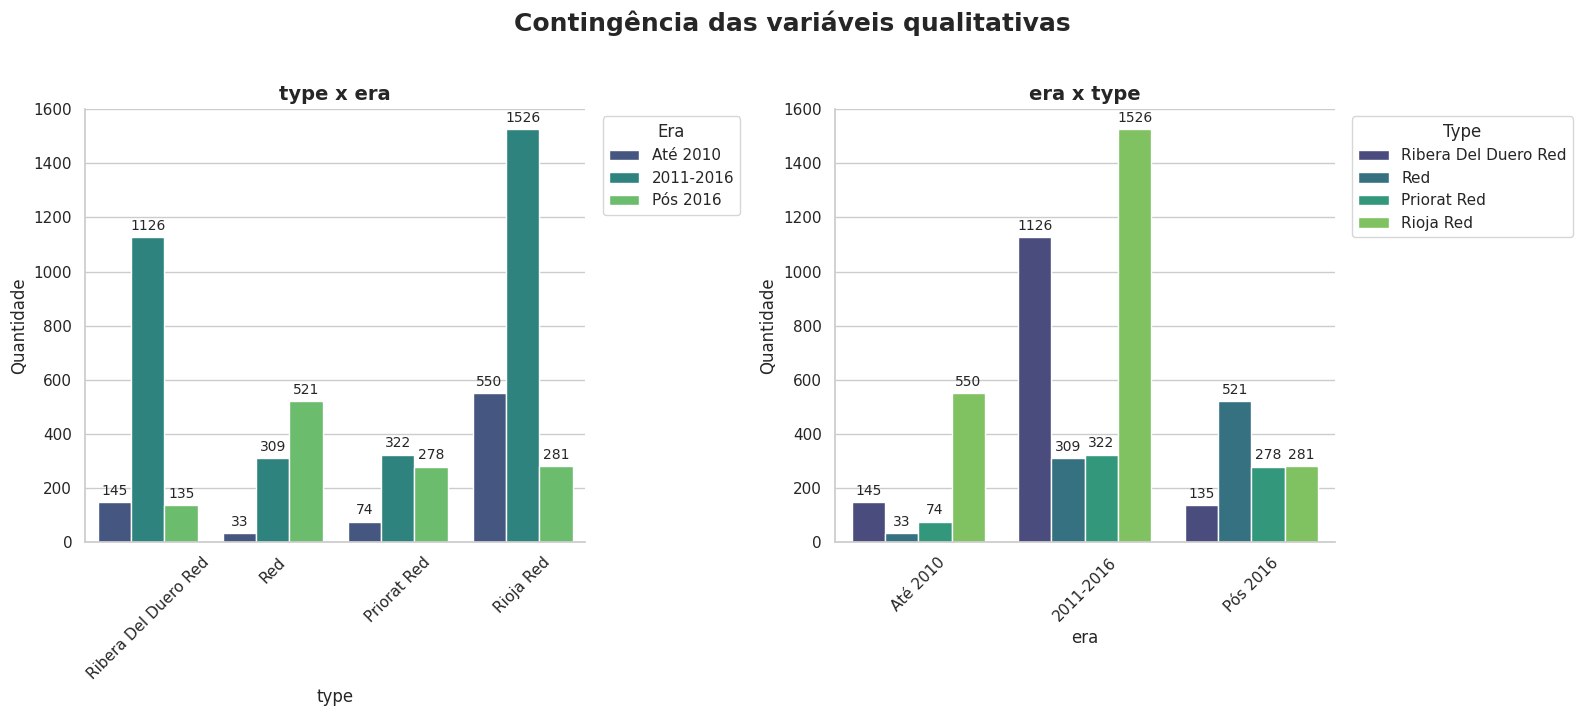

In [89]:
# @title Contingência das variáveis qualitativas — Contexto p/ Q3 e Q6

df_clean = df[df['year'] != 'N.V.'].copy()
df_clean['year'] = pd.to_numeric(df_clean['year'])
top_types = df_clean['type'].value_counts().nlargest(4).index
df_map = df_clean[df_clean['type'].isin(top_types)].copy()
df_map['era'] = pd.cut(df_map['year'], bins=[1900, 2010, 2016, 2022],
                       labels=['Até 2010', '2011-2016', 'Pós 2016'])

vars_qual = ['type', 'era']
combinacoes = list(itertools.permutations(vars_qual, 2))


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))
axes = axes.flatten()

for i, (v1, v2) in enumerate(combinacoes):
    plot = sns.countplot(data=df_map, x=v1, hue=v2, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{v1} x {v2}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Quantidade')


    for container in axes[i].containers:
        axes[i].bar_label(container, padding=3, fontsize=10)

    axes[i].legend(title=v2.capitalize(), bbox_to_anchor=(1.02, 1), loc='upper left')
    axes[i].tick_params(axis='x', rotation=45)
    sns.despine(ax=axes[i])

plt.suptitle('Contingência das variáveis qualitativas', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


---

> ℹ️ Esta contingência dá **contexto** para **Q3** (tipo × valor) e **Q6** (diversidade de tipos por região), respondidas de forma dedicada logo adiante.

- O catálogo é concentrado em vinhos da Espanha, com destaque para o tipo **Rioja Red**, o mais representativo, somando 2.357 unidades. Em seguida, **Ribera Del Duero Red** ocupa a segunda posição, com 1.407 registros.

- O maior volume de rótulos está concentrado no período de 2011 a 2016, que reúne 3.283 registros. Já as safras mais antigas (até 2010) representam a menor parcela do conjunto, com 802 unidades.

- Enquanto categorias específicas como **Rioja**, **Ribera** e **Priorat** apresentam queda nas safras mais recentes, o tipo genérico **"Red"** segue o movimento oposto. O volume cresce de 309 unidades (2011–2016) para 521 no período pós-2016, indicando uma expansão desse segmento nos anos mais novos.

- Há uma redução significativa no volume de **Rioja Red** nas safras mais recentes, passando de 1.526 (2011–2016) para 281 (pós-2016).

---


### Q6 — Diversidade de tipos de vinho por região (Top 10)

*Análise bivariada (qualitativa × qualitativa)* — número de tipos de vinho distintos em cada uma das 10 regiões com mais registros.

,n_registros,tipos_distintos,shannon,simpson
region,,,,
Rioja,2440,5,0.191,0.080
Jerez-Xeres-Sherry,246,2,0.129,0.055
Vino de Espana,263,6,0.125,0.038
Bierzo,238,2,0.068,0.025
Toro,299,4,0.067,0.020
Ribera del Duero,1411,3,0.025,0.007
Priorato,676,2,0.020,0.006
Alicante,228,1,-0.000,0.000
Mallorca,16,1,-0.000,0.000


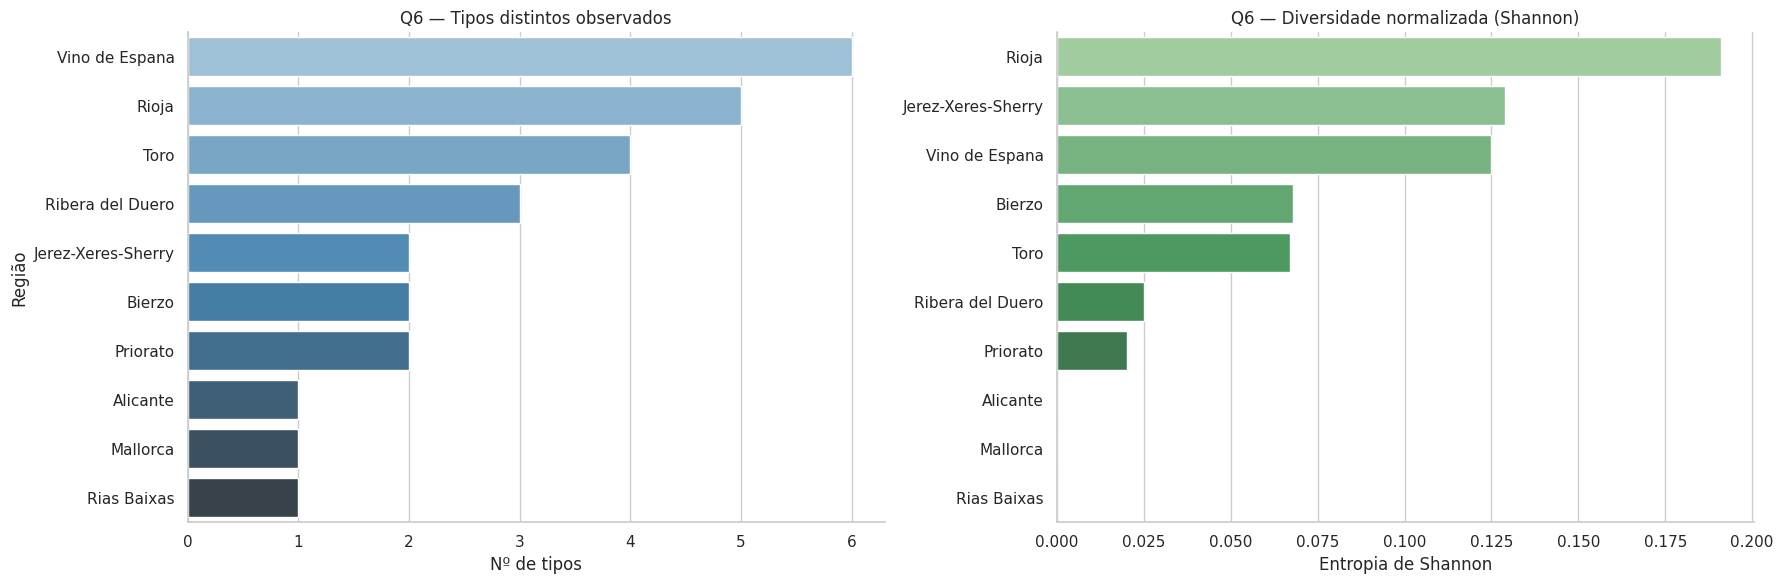

In [90]:
# @title Q6 — Diversidade de tipos por região (responde Q6)

def shannon_entropy(s):
    p = s.value_counts(normalize=True)
    return -(p * np.log(p)).sum()

def simpson_diversity(s):
    p = s.value_counts(normalize=True)
    return 1 - (p ** 2).sum()

top10_regioes = df['region'].value_counts().nlargest(10).index
df_q6 = df[df['region'].isin(top10_regioes) & df['type'].notna()].copy()

diversidade = (df_q6.groupby('region', observed=True)['type']
               .agg(n_registros='count', tipos_distintos='nunique',
                    shannon=shannon_entropy, simpson=simpson_diversity)
               .sort_values(['shannon', 'tipos_distintos'], ascending=False)
               .round(3))

display(diversidade)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ordem_tipos = diversidade.sort_values('tipos_distintos', ascending=False).index
sns.barplot(data=diversidade.loc[ordem_tipos].reset_index(),
            x='tipos_distintos', y='region', ax=axes[0],
            palette="Blues_d", hue='region', legend=False)
axes[0].set(title="Q6 — Tipos distintos observados", xlabel="Nº de tipos", ylabel="Região")

ordem_shannon = diversidade.sort_values('shannon', ascending=False).index
sns.barplot(data=diversidade.loc[ordem_shannon].reset_index(),
            x='shannon', y='region', ax=axes[1],
            palette="Greens_d", hue='region', legend=False)
axes[1].set(title="Q6 — Diversidade normalizada (Shannon)", xlabel="Entropia de Shannon", ylabel="")

sns.despine()
plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q6.**

A contagem de tipos distintos varia entre as regiões, mas essa métrica favorece regiões com mais registros e deve ser lida junto com medidas normalizadas. Por isso, a resposta usa dois olhares:

- **Tipos distintos observados:** mostra a variedade bruta dentro das 10 regiões mais frequentes.
- **Entropia de Shannon / Simpson:** considera também o equilíbrio da distribuição entre tipos, reduzindo a dependência do tamanho absoluto da região.

Com essa leitura, `Vino de Espana` continua sendo um caso particular por ser um rótulo genérico, não uma denominação comparável diretamente às regiões tradicionais. Regiões com denominação forte podem ter poucos tipos e baixa entropia justamente por concentração estilística, não por "menor diversidade real" no sentido amplo.

**Conclusão:** a hipótese de Q6 é sustentada como **variação observada de composição por região**, mas não como prova isolada de diversidade produtiva. Para uma conclusão mais forte, seria necessário balancear tamanhos amostrais ou aplicar rarefação.

---


### Relação entre variáveis quantitativas e qualitativas

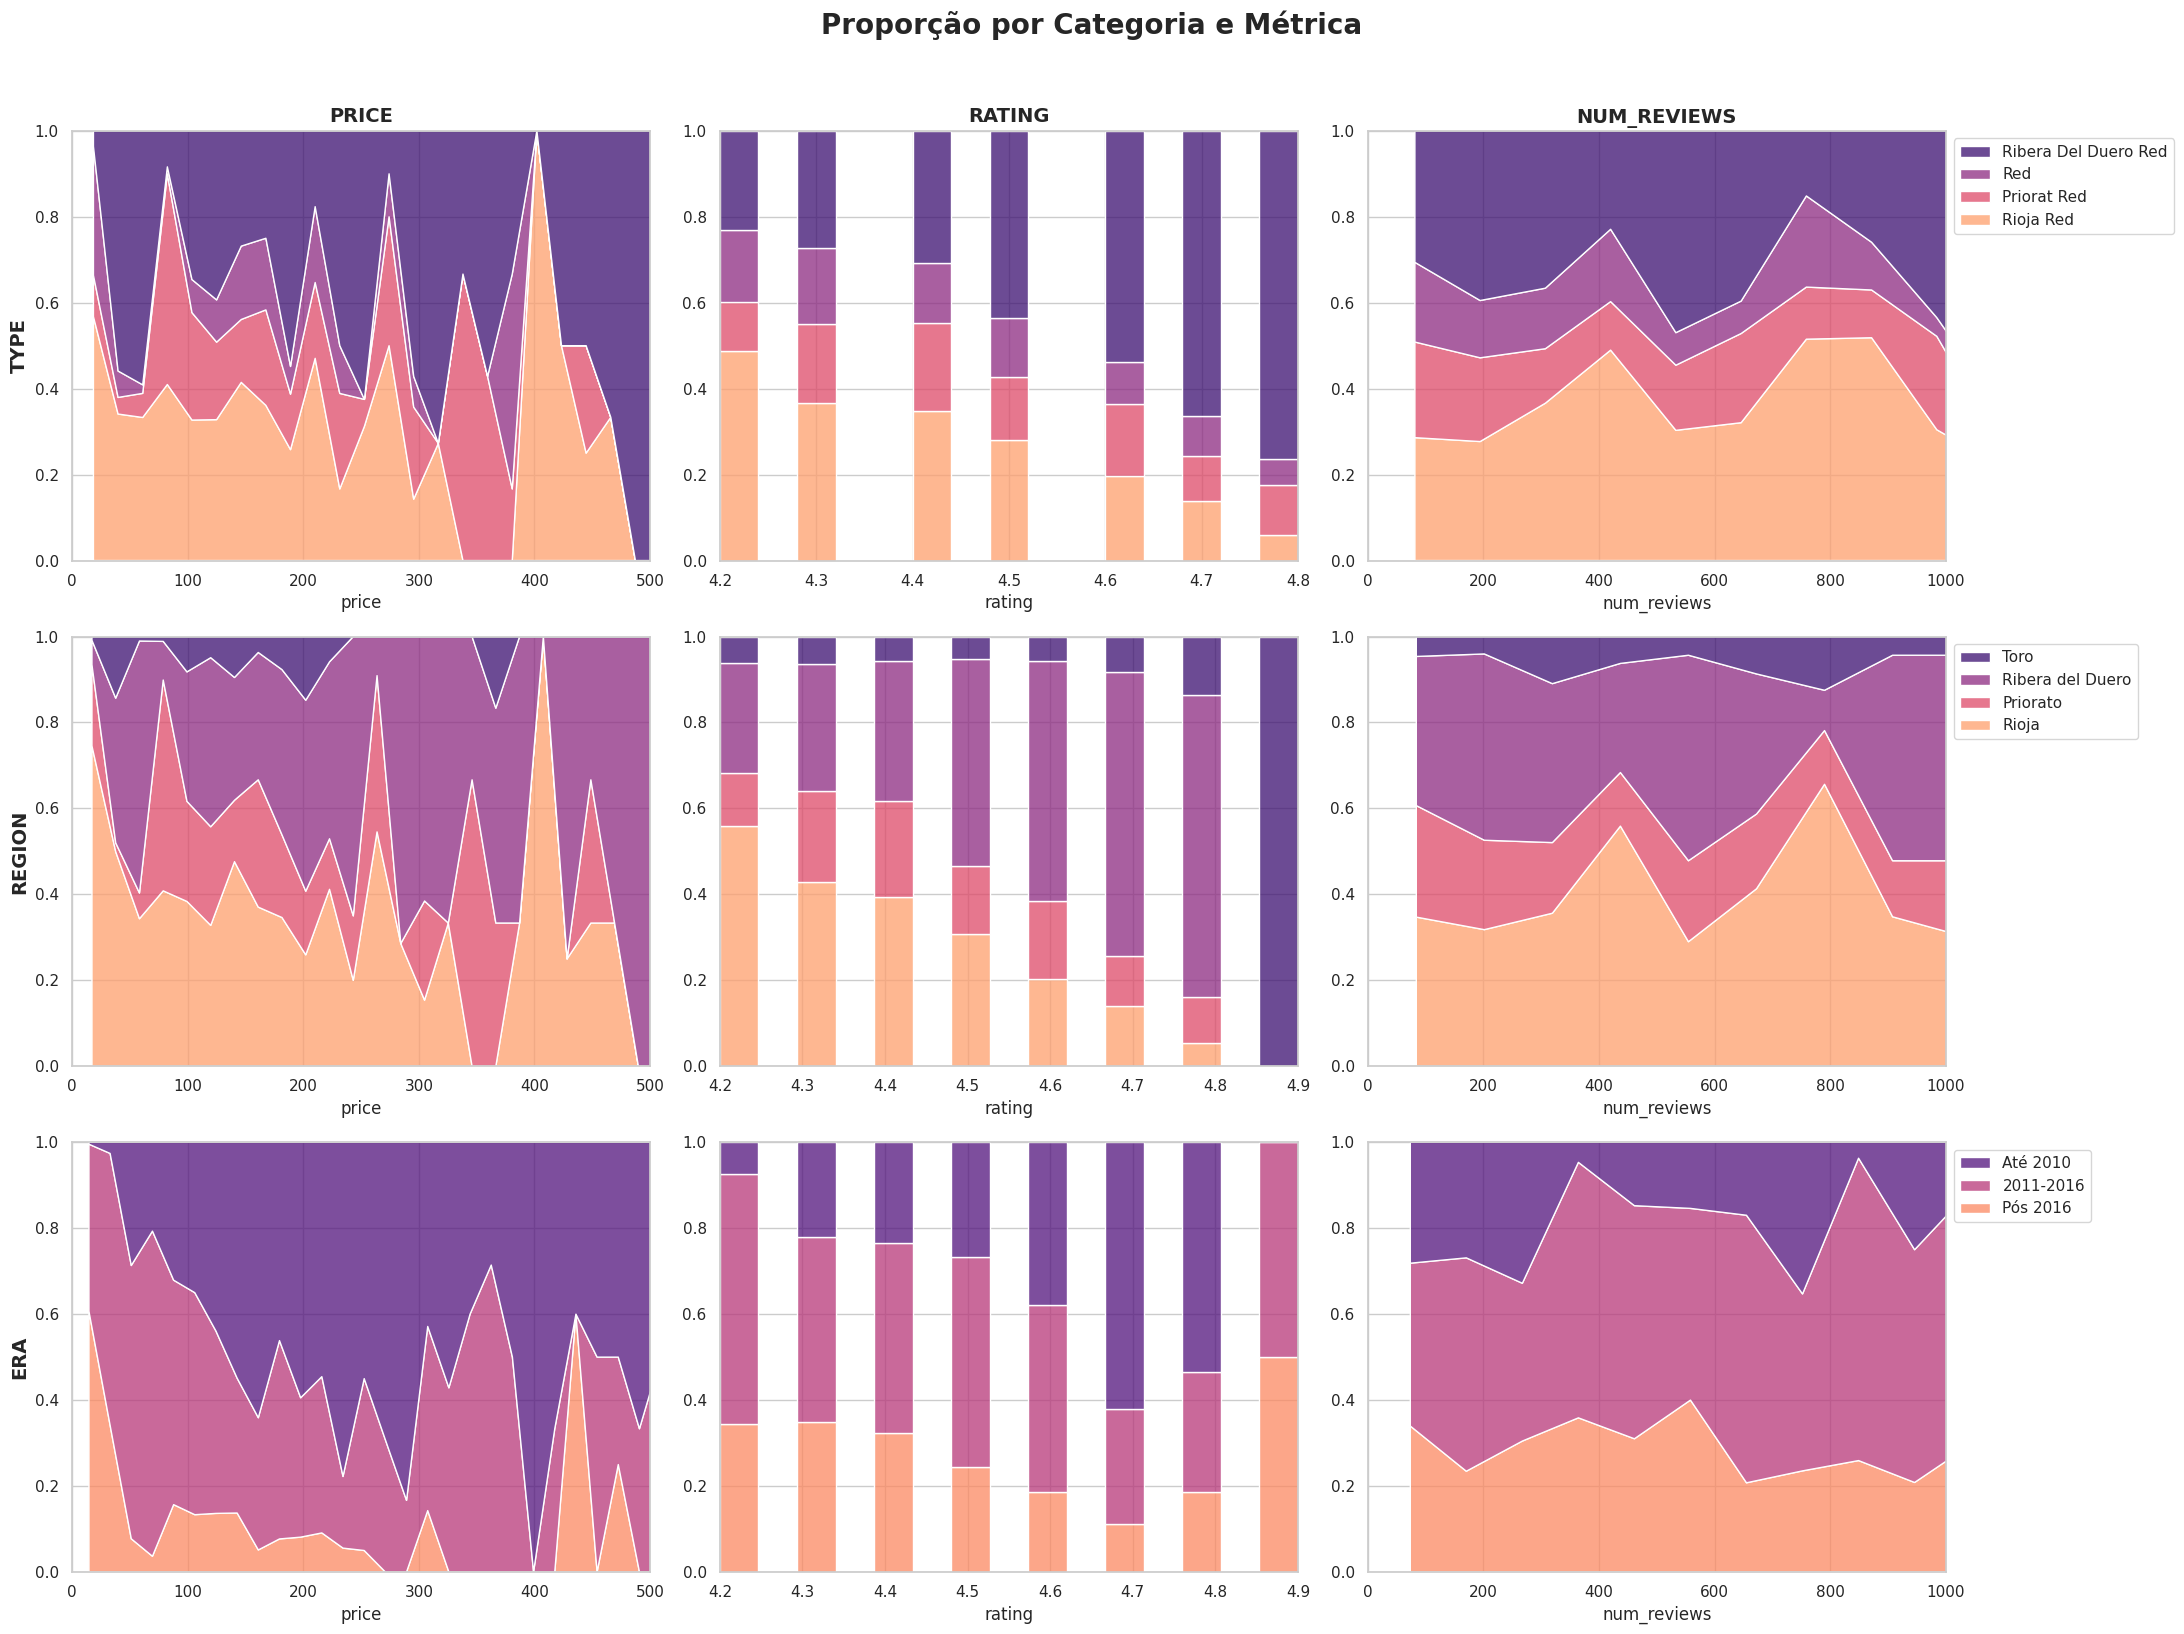

In [91]:
# @title Proporção por Categoria e Métrica — Contexto p/ Q2 (região × rating) e Q3 (tipo × preço)

if 'era' not in df_clean.columns:
    df_clean['era'] = pd.cut(df_clean['year'], bins=[1900, 2010, 2016, 2022],
                             labels=['Até 2010', '2011-2016', 'Pós 2016'])

qual_vars_impacto = ['type', 'region', 'era']
quant_vars_impacto = ['price', 'rating', 'num_reviews']

fig, axes = plt.subplots(nrows=len(qual_vars_impacto), ncols=len(quant_vars_impacto), figsize=(22, 16))

for row, qual in enumerate(qual_vars_impacto):

    top_items = df_clean[qual].value_counts().nlargest(4).index
    df_temp = df_clean[df_clean[qual].isin(top_items)].copy()

    for col, quant in enumerate(quant_vars_impacto):

        if quant == 'rating':
            sns.histplot(data=df_temp, x=quant, hue=qual, multiple='fill',
                         ax=axes[row, col], palette='magma',
                         bins=15,
                         legend=(col == len(quant_vars_impacto) - 1))
        else:
            sns.histplot(data=df_temp, x=quant, hue=qual, multiple='fill',
                         ax=axes[row, col], palette='magma', element='poly',
                         shrink=1, legend=(col == len(quant_vars_impacto) - 1))

        if row == 0:
            axes[row, col].set_title(quant.upper(), fontsize=14, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(qual.upper(), fontsize=14, fontweight='bold')
        else:
            axes[row, col].set_ylabel('')

        if quant == 'price': axes[row, col].set_xlim(0, 500)
        if quant == 'num_reviews': axes[row, col].set_xlim(0, 1000)

        if col == len(quant_vars_impacto) - 1:
            sns.move_legend(axes[row, col], "upper left", bbox_to_anchor=(1, 1), title=None)

plt.suptitle('Proporção por Categoria e Métrica', fontsize=20, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

---

#### Refinamento e Seleção de Variáveis

Nesta etapa, a seleção de variáveis prioriza clareza visual. Variáveis como *Winery* e *Wine* são omitidas da grade por terem alta cardinalidade e dificultarem a identificação de padrões gerais.

As variáveis *Body* e *Acidity* tinham 1.169 valores ausentes (~15% do dataset), já tratados na etapa *Tratamento de Valores Nulos* (imputação pela mediana do `type` + flags de ausência). Mesmo com os dados completos, esta grade permanece focada em *Type*, *Region* e *Era*, enquanto `body` e `acidity` são analisadas em perguntas dedicadas com valores originalmente medidos.

A matriz final destaca onde se concentram preço (`price`), avaliação (`rating`) e popularidade (`num_reviews`) dentro dos principais recortes categóricos.

---

#### Price

- No gráfico por *Type*, observa-se que **Ribera Del Duero Red** ganha participação conforme o preço aumenta, especialmente nas faixas mais altas.

- O tipo **Rioja Red** concentra muitos vinhos nas faixas de preço mais baixas e intermediárias, com participação menor nas faixas superiores.

- Na análise por *Era*, vinhos até 2010 aparecem com maior presença nas faixas altas de preço. Essa é uma associação exploratória, não uma atribuição causal à idade.

#### Rating

- Vinhos das eras até 2010 e 2011-2016 aparecem com maior presença nas notas 4.8 e 4.9.

- Vinhos pós-2016 aparecem com frequência nas notas intermediárias, como 4.3 e 4.4, indicando bom desempenho dentro de uma base já concentrada em ratings altos.

#### Num_Reviews

- A era 2011-2016 apresenta maior participação em diferentes faixas de número de avaliações.

- Na análise por região, **Toro** aparece com participação menor em número de avaliações quando comparado com **Rioja** e **Priorato**.

---


### Q2 — Região × Avaliação

*Análise bivariada (qualitativa × quantitativa)* — relação entre a região produtora e a nota (`rating`).

,n,media,mediana,desvio
region,,,,
Ribera del Duero,1413,4.297,4.2,0.161
Priorato,686,4.273,4.2,0.126
Toro,300,4.266,4.2,0.141
Vino de Espana,263,4.244,4.2,0.113
Rioja,2440,4.233,4.2,0.085
Jerez-Xeres-Sherry,247,4.219,4.2,0.072
Bierzo,244,4.218,4.2,0.071
Rias Baixas,252,4.215,4.2,0.050
Mallorca,237,4.215,4.2,0.061


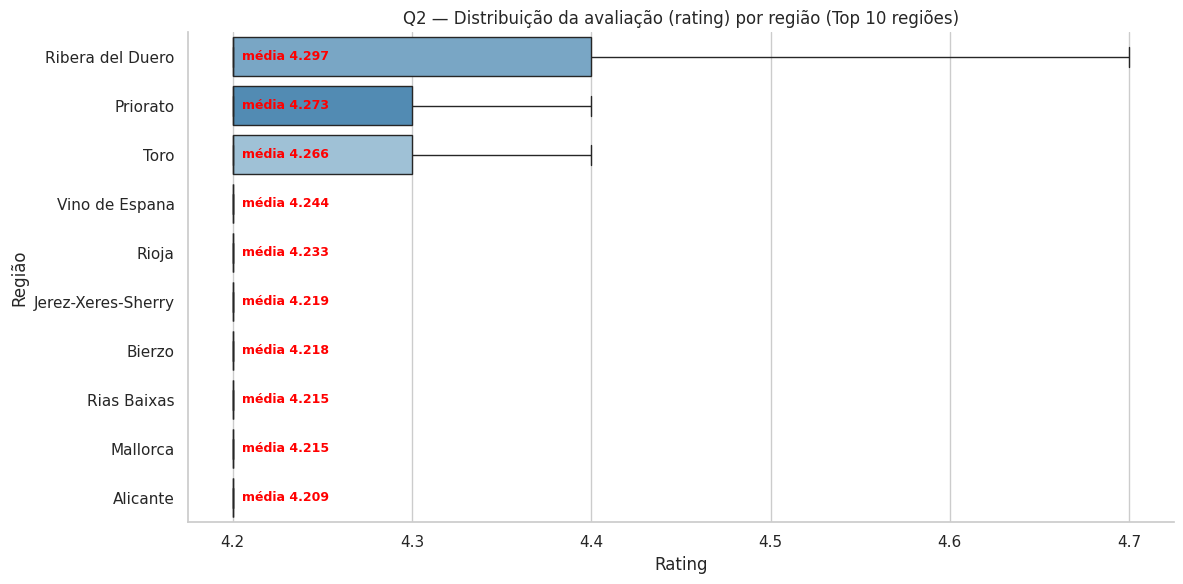

In [92]:
# @title Q2 — Região × Avaliação (responde Q2)

top_regioes_q2 = df['region'].value_counts().nlargest(10).index
df_q2 = df[df['region'].isin(top_regioes_q2)]

resumo_q2 = (df_q2.groupby('region', observed=True)['rating']
             .agg(n='count', media='mean', mediana='median', desvio='std')
             .sort_values('media', ascending=False)
             .round(3))
display(resumo_q2)

ordem_q2 = resumo_q2.index

plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df_q2, x='rating', y='region', order=ordem_q2,
                 palette="Blues_d", hue='region', legend=False, showfliers=False)

for i, m in enumerate(resumo_q2['media'].values):
    ax.text(4.205, i, f'média {m:.3f}', va='center', fontsize=9,
            color='red', fontweight='bold')

ax.set(title="Q2 — Distribuição da avaliação (rating) por região (Top 10 regiões)",
       xlabel="Rating", ylabel="Região")
sns.despine()
plt.tight_layout()
plt.show()


---

> ✅ **Resposta da Pergunta Q2.**

Como o dataset contém apenas vinhos já bem avaliados (rating mínimo = 4.2), a **mediana é 4.2 em todas as regiões** na base bruta. A diferença aparece na média e na cauda superior.

A leitura correta é associativa: algumas regiões aparecem com ratings médios ligeiramente maiores, mas a diferença é moderada e acontece dentro de uma base já filtrada para notas altas.

**Conclusão:** a hipótese de Q2 se sustenta de forma **moderada** como associação observada entre região e avaliação, não como evidência causal de que a região, isoladamente, "afeta" a nota. Para afirmar efeito próprio da região, seria necessário controlar tipo, safra, preço e possíveis duplicatas.

---


### Q3 — Tipo de vinho × Preço

*Análise bivariada (qualitativa × quantitativa)* — relação entre o tipo de vinho e o `price`.

,n,mediana,media
type,,,
Priorat Red,674,77.36,104.79
Ribera Del Duero Red,1407,51.35,109.45
Tempranillo,291,48.96,73.41
Rioja White,92,29.15,48.85
Rioja Red,2357,28.53,43.97
Toro Red,296,27.89,76.52
Red,864,23.95,37.49
Mencia,235,17.90,21.24
Albarino,252,16.78,18.11


#### Tamanho de efeito por ranks (Kruskal-Wallis descritivo)

,H,epsilon2,n,k
0,2019.8902,0.2987,6742.0,10.0


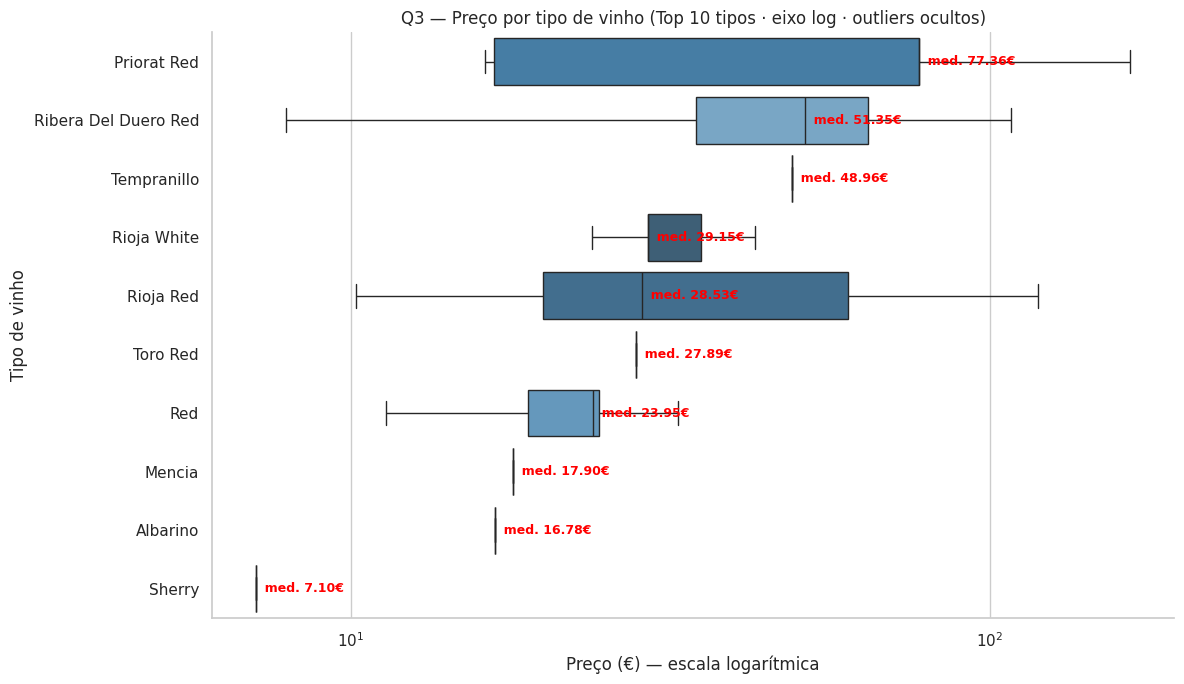

In [93]:
# @title Q3 — Tipo de vinho × Preço (responde Q3)

top_tipos_q3 = df['type'].value_counts().nlargest(10).index
df_q3 = df[df['type'].isin(top_tipos_q3)]

resumo_q3 = (df_q3.groupby('type', observed=True)['price']
             .agg(n='count', mediana='median', media='mean')
             .sort_values('mediana', ascending=False)
             .round(2))
display(resumo_q3)

display(Markdown("#### Tamanho de efeito por ranks (Kruskal-Wallis descritivo)"))
display(kruskal_epsilon2(df_q3, 'type', 'price').to_frame().T.round(4))

ordem_q3 = resumo_q3.index

plt.figure(figsize=(12, 7))
ax = sns.boxplot(data=df_q3, x='price', y='type', order=ordem_q3,
                 palette="Blues_d", hue='type', legend=False, showfliers=False)
ax.set_xscale('log')

for i, m in enumerate(resumo_q3['mediana'].values):
    ax.text(m, i, f'  med. {m:.2f}€', va='center', fontsize=9,
            color='red', fontweight='bold')

ax.set(title="Q3 — Preço por tipo de vinho (Top 10 tipos · eixo log · outliers ocultos)",
       xlabel="Preço (€) — escala logarítmica", ylabel="Tipo de vinho")
sns.despine()
plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q3.**

O tipo de vinho está associado a faixas de preço muito diferentes (eixo em escala logarítmica para comportar a amplitude). A comparação por medianas é mais apropriada do que a média, porque `price` é fortemente assimétrico.

- Tipos ligados a denominações prestigiadas, como **Priorat Red** e **Ribera Del Duero Red**, aparecem entre as maiores medianas.
- Tipos mais numerosos e populares, como **Rioja Red**, concentram muitas observações em faixas intermediárias.
- A estatística por ranks reforça que há separação entre grupos, mas isso ainda é uma associação: `type` carrega informação de região, estilo, safra e posicionamento de mercado.

**Conclusão:** a hipótese de Q3 se sustenta como associação forte entre tipo e preço. A redação evita dizer que o tipo, sozinho, causa o preço.

---


# Análise Multivariada

#### Resumo por era — base temporal completa

,n,preco_mediano,preco_medio,rating_mediano,rating_medio
era,,,,,
Até 2010,901,73.0,194.31,4.3,4.35
2011-2016,3917,33.9,51.57,4.2,4.24
Pós 2016,2392,18.9,27.76,4.2,4.24


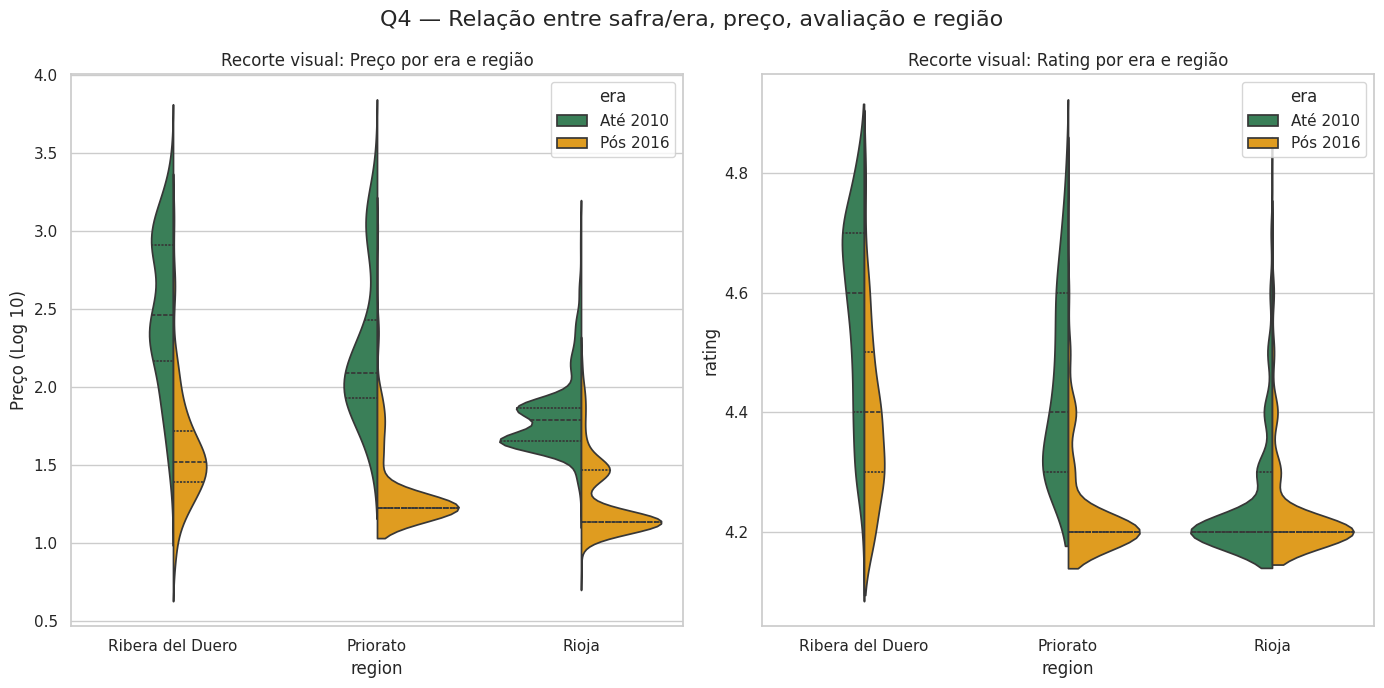

In [94]:
# @title Distribuição Conjunta — Q4 (avaliação, preço e ano)

# Preparar dados: converter year e criar coluna era.
df_temp_for_era = df.copy()
df_temp_for_era['year_num'] = pd.to_numeric(df_temp_for_era['year'], errors='coerce')
df_temp_for_era = df_temp_for_era.dropna(subset=['year_num'])
df_temp_for_era['era'] = pd.cut(df_temp_for_era['year_num'], bins=[1900, 2010, 2016, 2022],
                                labels=['Até 2010', '2011-2016', 'Pós 2016'])

resumo_eras = (df_temp_for_era.groupby('era', observed=True)
               .agg(n=('price', 'count'),
                    preco_mediano=('price', 'median'),
                    preco_medio=('price', 'mean'),
                    rating_mediano=('rating', 'median'),
                    rating_medio=('rating', 'mean'))
               .round(2))
display(Markdown("#### Resumo por era — base temporal completa"))
display(resumo_eras)

# Recorte visual: três regiões mais frequentes nos extremos temporais.
df_final = df_temp_for_era[df_temp_for_era['era'].isin(['Até 2010', 'Pós 2016'])].copy()
df_final['era'] = df_final['era'].cat.remove_unused_categories()

top_regions = df_final['region'].value_counts().nlargest(3).index
df_final = df_final[df_final['region'].isin(top_regions)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

sns.violinplot(
    data=df_final, x='region', y=np.log10(df_final['price']),
    hue='era', split=True, inner="quart", palette={"Até 2010": "seagreen", "Pós 2016": "orange"},
    ax=ax1
)
ax1.set_title('Recorte visual: Preço por era e região')
ax1.set_ylabel('Preço (Log 10)')

sns.violinplot(
    data=df_final, x='region', y='rating',
    hue='era', split=True, inner="quart", palette={"Até 2010": "seagreen", "Pós 2016": "orange"},
    ax=ax2
)
ax2.set_title('Recorte visual: Rating por era e região')

plt.suptitle('Q4 — Relação entre safra/era, preço, avaliação e região', fontsize=16)
plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q4** (avaliação, preço e ano) — com recorte visual por região.

A análise agora separa duas camadas:

1. **Resumo por era na base temporal completa:** mostra o comportamento geral de preço e rating para todos os registros com ano numérico.
2. **Recorte visual interpretável:** compara apenas as eras extremas (*Até 2010* vs. *Pós 2016*) nas três regiões mais frequentes desse recorte.

Esse recorte melhora a legibilidade, mas não é usado sozinho para "confirmar" a hipótese. Ele serve como visualização complementar de um padrão sugerido pelo resumo geral.

**Leitura:** vinhos de eras mais antigas aparecem associados a preços medianos mais altos e maior presença nas notas superiores. Ainda assim, safra, região, tipo, prestígio e preço estão confundidos; portanto, a conclusão deve ser associativa.

> **Conclusão de Q4:** a hipótese é compatível com os dados exploratórios: safras mais antigas e bem avaliadas tendem a aparecer em patamares de preço mais altos. Para afirmar efeito próprio da safra, seria necessário um modelo controlando região, tipo e outras variáveis.

---


## Q7 — Corpo × Preço × Região (vinhos com avaliação alta)

*Análise multivariada exploratória* — cruza `body`, `price` e `region` usando apenas vinhos com `rating >= 4.5`. Esse corte é informativo porque o dataset tem nota mínima 4.2; o filtro anterior (`rating > 4.0`) incluía toda a base. A análise usa apenas registros com `body` **originalmente medido** (`body_informado = 1`).


#### Registros analisados: rating >= 4.5

,n,mediana,media
body,,,
2,11,99.00,105.62
3,18,50.42,123.20
4,269,125.05,268.65
5,314,168.98,369.10


#### Tamanho de efeito por ranks (Kruskal-Wallis descritivo)

,H,epsilon2,n,k
0,18.8389,0.0261,612.0,4.0


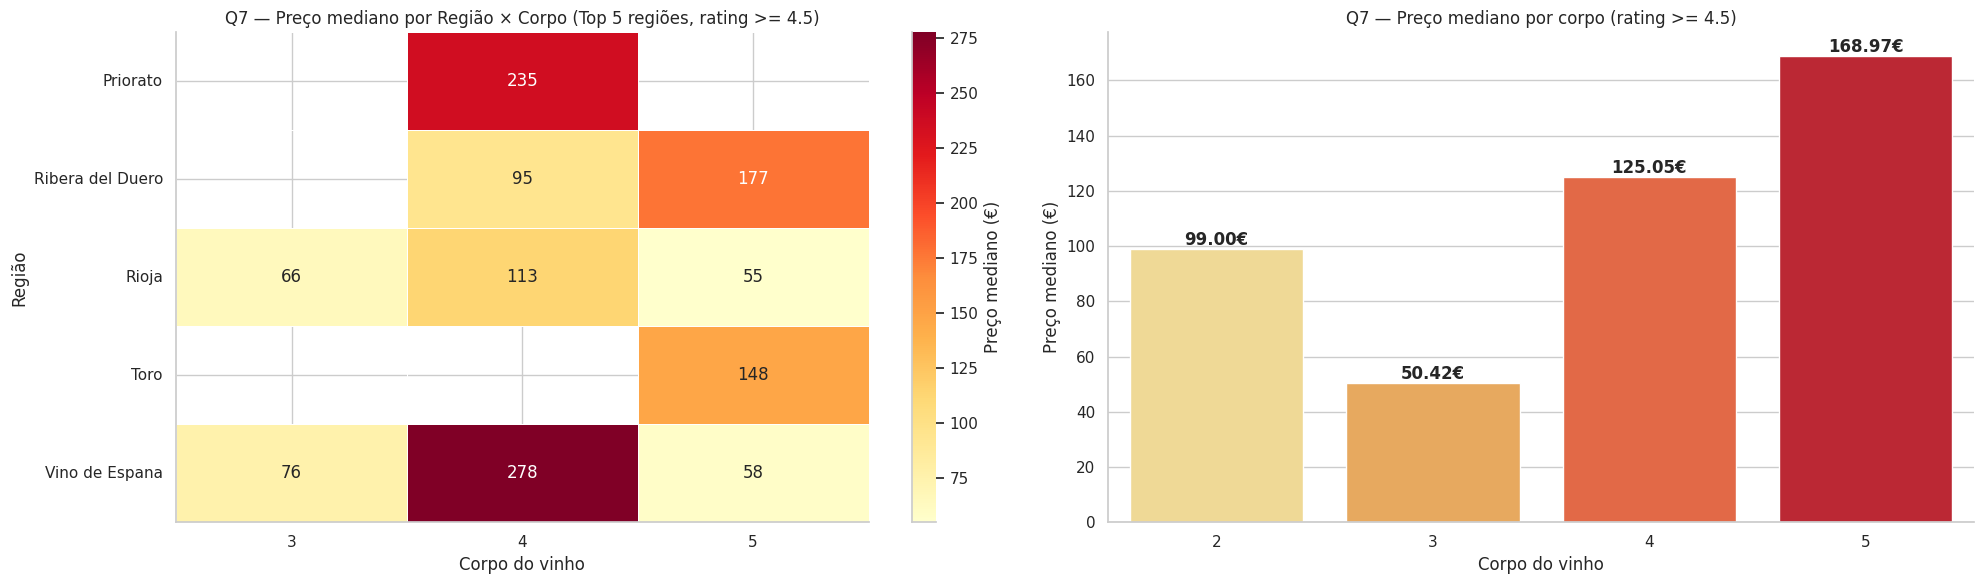

In [95]:
# @title Q7 — Corpo × Preço × Região (rating >= 4.5)

limiar_rating_q7 = 4.5

# Usa apenas body ORIGINALMENTE medido (flag), não os imputados.
df_q7 = df[(df['rating'] >= limiar_rating_q7) & (df['body_informado'] == 1)].copy()

display(Markdown(f"#### Registros analisados: rating >= {limiar_rating_q7}"))
display(resumo_por_grupo(df_q7, 'body', 'price'))

display(Markdown("#### Tamanho de efeito por ranks (Kruskal-Wallis descritivo)"))
display(kruskal_epsilon2(df_q7, 'body', 'price').to_frame().T.round(4))

top_regioes_q7 = df_q7['region'].value_counts().nlargest(5).index
df_q7_top = df_q7[df_q7['region'].isin(top_regioes_q7)]

pivot_q7 = df_q7_top.pivot_table(index='region', columns='body',
                                 values='price', aggfunc='median', observed=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(pivot_q7, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=.5, ax=axes[0], cbar_kws={'label': 'Preço mediano (€)'})
axes[0].set(title="Q7 — Preço mediano por Região × Corpo (Top 5 regiões, rating >= 4.5)",
            xlabel="Corpo do vinho", ylabel="Região")

med_body = df_q7.groupby('body', observed=True)['price'].median()
sns.barplot(x=med_body.index.astype(str), y=med_body.values, ax=axes[1],
            palette="YlOrRd", hue=med_body.index.astype(str), legend=False)
for i, v in enumerate(med_body.values):
    axes[1].text(i, v, f'{v:.2f}€', ha='center', va='bottom', fontweight='bold')
axes[1].set(title="Q7 — Preço mediano por corpo (rating >= 4.5)",
            xlabel="Corpo do vinho", ylabel="Preço mediano (€)")

sns.despine()
plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q7.** O filtro agora usa `rating >= 4.5`, pois `rating > 4.0` abrangia todo o dataset. Também são usados apenas registros com `body` originalmente medido.

**Leitura geral:** entre vinhos de avaliação alta, preços medianos tendem a ser maiores nos níveis mais altos de corpo. No entanto, o padrão não deve ser lido como efeito causal do corpo: `body` está fortemente associado a estilo, tipo e região.

**Leitura por região:** o mapa de calor mostra que o patamar de preço muda bastante entre regiões mesmo para o mesmo nível de corpo. Em algumas regiões, certos níveis de corpo quase não aparecem, o que limita comparações diretas.

**Conclusão:** a hipótese de Q7 é **compatível** com os dados como associação exploratória: vinhos mais encorpados e com rating alto tendem a ocupar faixas de preço maiores. Para testar se `body` acrescenta informação própria, o próximo passo seria modelar `log(price)` controlando `region`, `type` e `year/era`.

---


## Mapa de Calor e Dispersão

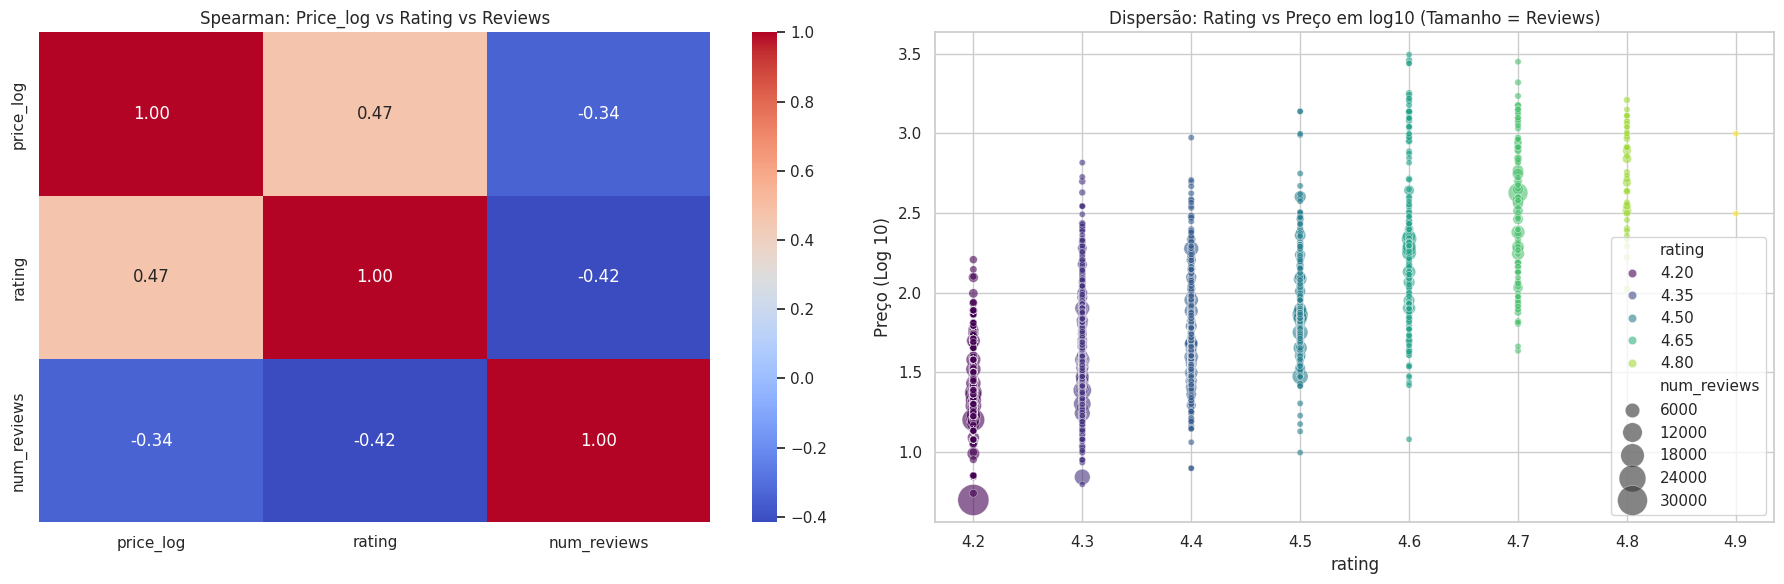

In [96]:
# @title Mapa de Calor e Dispersão — Responde Q1 (avaliação × preço)

df_quant = df.copy()
df_quant['price_log'] = np.log10(df_quant['price'])

corr_q1 = df_quant[['price_log', 'rating', 'num_reviews']].corr(method='spearman')

fig, axes = plt.subplots(figsize=(18, 6), ncols=2)

sns.heatmap(corr_q1, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("Spearman: Price_log vs Rating vs Reviews")

sns.scatterplot(
    data=df_quant,
    x='rating',
    y='price_log',
    size='num_reviews',
    hue='rating',
    palette='viridis',
    sizes=(20, 500),
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title("Dispersão: Rating vs Preço em log10 (Tamanho = Reviews)")
axes[1].set_ylabel("Preço (Log 10)")

plt.tight_layout()
plt.show()


> **Resposta da Pergunta Q1** (avaliação × preço).

O mapa de calor usa **Spearman** porque `rating` tem poucos níveis ordenados e `price` é muito assimétrico. A associação entre `rating` e `price_log` é positiva: vinhos com notas maiores tendem a aparecer em faixas de preço mais altas.

Essa evidência sustenta a hipótese de Q1 em termos associativos. Ainda assim, a pontuação não deve ser descrita como algo que "explica" o preço sozinha, pois região, tipo, safra, prestígio e disponibilidade também estão envolvidos.

> **Conclusão de Q1:** a hipótese é compatível com os dados — maior avaliação está associada a maior valor de mercado —, sem interpretação causal isolada.


## Análise dos Resultados

### Síntese geral

Esta EDA investigou 7.500 registros de vinhos espanhóis cobrindo 76 regiões, 21 tipos e várias décadas de safras. As conclusões abaixo são formuladas como **associações exploratórias**, não como relações causais.

---

### 1. Avaliação e preço: associação positiva (Q1)

`rating` está positivamente associado ao preço, especialmente quando `price` é analisado em escala logarítmica. Isso sugere que vinhos mais bem avaliados tendem a ocupar faixas de preço superiores, mas não significa que a nota, isoladamente, determine o preço.

---

### 2. Região, tipo e safra aparecem como marcadores de posicionamento (Q2, Q3, Q4)

Região, tipo e era/safra estão associados a diferenças de rating e preço. Esses fatores carregam informação de denominação, estilo, maturidade e prestígio. Por isso, as conclusões evitam linguagem causal: a EDA mostra estratificação de mercado, mas não separa completamente os efeitos próprios de cada variável.

---

### 3. Número de reviews não sustenta a hipótese de preço baixo = mais avaliações (Q5)

A relação linear entre `num_reviews` e preço/rating é fraca. A análise por Spearman deve ser considerada junto com Pearson porque há assimetria e muitos empates, mas a hipótese original de que vinhos mais baratos recebem claramente mais reviews não se confirma de forma robusta.

---

### 4. Corpo e acidez exigem leitura ordinal (Q7, Q8)

`body` e `acidity` são escalas ordinais discretas. Por isso, a leitura principal usa medianas, Spearman e tamanho de efeito por grupos. Para Q7, o corte foi corrigido para `rating >= 4.5`, tornando a análise realmente focada em vinhos de avaliação alta. Para Q8, a hipótese de acidez moderada mais cara não se sustentou, mas a categoria de acidez baixa é muito pequena e não permite generalização forte.

---

### 5. Valores ausentes são informativos, mas o mecanismo não é provado

A ausência de `body`/`acidity` varia com preço, o que é evidência contra MCAR. O padrão é compatível com MAR condicionado a variáveis observadas, mas não prova MAR. As flags de ausência preservam esse sinal e permitem separar análises com valores observados de análises com valores imputados.

---

### Conclusão

O mercado representado no dataset parece estruturado por avaliação, tipo/região e safra/era, com `body` e `acidity` atuando como características ordinais de estilo. As conclusões devem ser lidas como associações exploratórias. Uma etapa futura natural seria ajustar modelos de `log(price)` controlando simultaneamente `rating`, `type`, `region`, `year/era`, `body` e indicadores de ausência.


# Resultados

## Tabela de Perguntas, Hipóteses e Resultados

| # | Pergunta | Hipótese | Resultado | Achado-chave | Categoria |
|---|---|---|---|---|---|
| **Q1** | Há relação entre avaliação e preço? | Maior avaliação → maior preço | **Compatível** | `rating` se associa positivamente a `price_log`; leitura em Spearman/log é mais adequada | Bivariada / Multivariada |
| **Q2** | Região se associa à avaliação? | Regiões renomadas têm avaliações superiores | **Compatível, com efeito moderado** | Médias variam, mas as medianas são muito próximas porque o dataset já concentra notas altas | Bivariada |
| **Q3** | O tipo de vinho se associa ao valor? | Existem tipos sistematicamente mais caros | **Compatível** | Tipos ligados a denominações prestigiadas aparecem em faixas de preço mais altas | Bivariada |
| **Q4** | Qual a relação entre avaliação, preço e ano? | Vinhos antigos e bem avaliados são mais caros | **Compatível no recorte exploratório** | Eras antigas tendem a apresentar preços medianos maiores; recorte visual não implica causalidade | Multivariada |
| **Q5** | Existe relação entre preço e nº de reviews? | Vinhos mais baratos têm mais reviews | **Não confirmada** | A relação linear é fraca; Spearman é usado como complemento por causa da assimetria | Bivariada |
| **Q6** | Como varia a diversidade de tipos entre as 10 principais regiões? | Algumas regiões são mais diversas por clima, solo e tradição | **Compatível com ressalva** | Contagem bruta é complementada por Shannon/Simpson; `Vino de Espana` é categoria genérica | Bivariada (qual × qual) |
| **Q7** | Como o corpo se associa ao preço em vinhos com `rating >= 4.5`? | Vinhos mais encorpados e bem avaliados são mais caros | **Compatível como associação** | Preço mediano tende a subir com corpo, mas região/tipo confundem a relação | Multivariada |
| **Q8** | A acidez se associa ao preço? | Acidez moderada associada a preços mais altos | **Não confirmada** | Acidez baixa tem poucos registros; não há base para generalizar relação inversa | Bivariada |
